In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
import joblib

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, cross_val_predict, GridSearchCV,
    RandomizedSearchCV, learning_curve, validation_curve
)
from sklearn.metrics import (
    make_scorer, mean_squared_error, classification_report, accuracy_score, roc_auc_score,
    roc_curve, confusion_matrix, precision_score, recall_score, f1_score, cohen_kappa_score,
    matthews_corrcoef, average_precision_score, auc, precision_recall_curve
)
from sklearn.preprocessing import (
    OrdinalEncoder, OneHotEncoder, KBinsDiscretizer, Binarizer, StandardScaler,
    MinMaxScaler, RobustScaler, LabelEncoder, FunctionTransformer, PowerTransformer
)
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import (
    VarianceThreshold, SelectFromModel, SelectKBest, f_classif, mutual_info_classif
)
from sklearn.datasets import make_classification, load_iris
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn import set_config

# Opcjonalnie: ustawienie konfiguracji scikit-learn
set_config(display="diagram")  # Wyświetlanie diagramów potoków

# Opcjonalnie: wyłączenie ostrzeżeń
import warnings
warnings.filterwarnings("ignore")

# Konfiguracja wyjścia dla transformacji
set_config(transform_output='pandas')

# Setting display options for pandas
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
import markdown
from IPython.display import display, Markdown

# I. Wprowadzenie

### 1. Cel projektu


> Stworzenie modelu, który przewiduje, czy klient banku otrzyma kredyt hipoteczny.

# II. Wczytanie i wstępne przetwarzanie danych

### 1. Wczytanie danych źródłówych

> Dane do budowy modelu uczenia maszynowego zostały wygenerowne syntetycznie za pomocą kodu python. 

> Są to dane fikcyjne wygenerowane w celu demonstracyjnym.

> Wygenerowane dane zawierają wiele zmiennych , które zostana wykorzystane do budowy modelu klasyfikacyjnego, które celem jest ustalenie czy klient banku w oparciu o wybrane zmienne/cechy otrzyma kredyt hipoteczny , czy nie otrzyma.

> Wygenerowane dane zostały zapisane do pliku excel.

In [5]:

# ====================================================================
# 1. Wczytanie i wstępne przetwarzanie danych
# ====================================================================

## 1.1. Wczytanie danych z pliku Excel
df = pd.read_excel('synthetic_data.xlsx')



### 2. Podstawowe informacje o danych

In [19]:
display(Markdown("**Wgląd w strukturę danych:**"))

def analiza_dataframe(df):
    # Liczba kolumn
    liczba_kolumn = len(df.columns)
    
    # Liczba wierszy
    liczba_wierszy = len(df)
    
    # Liczba kolumn numerycznych, tekstowych, dat i boolowskich
    liczba_kolumn_numerycznych = len(df.select_dtypes(include='number').columns)
    liczba_kolumn_textowych = len(df.select_dtypes(include='object').columns)
    liczba_kolumn_dat = len(df.select_dtypes(include='datetime').columns)
    liczba_kolumn_bool = len(df.select_dtypes(include='bool').columns)

    # Tworzenie DataFrame z wynikami
    wyniki = pd.DataFrame({
        'Liczba kolumn': [liczba_kolumn],
        'Liczba wierszy': [liczba_wierszy],
        'Liczba kolumn numerycznych': [liczba_kolumn_numerycznych],
        'Liczba kolumn tekstowych': [liczba_kolumn_textowych],
        'Liczba kolumn dat': [liczba_kolumn_dat],
        'Liczba kolumn bool': [liczba_kolumn_bool]
    })
    wyniki = wyniki.sort_values(by='Liczba kolumn numerycznych', ascending=False).reset_index(drop=True)
    return wyniki




import pandas as pd

def informacje_o_dataframe(df, dodatkowe_kolumny_numeryczne=None):
    informacje = []

    if dodatkowe_kolumny_numeryczne is None:
        dodatkowe_kolumny_numeryczne = []

    for kolumna in df.columns:
        typ_kolumny = df[kolumna].dtype
        unikalne_wartosci = df[kolumna].nunique()
        puste_wartosci = df[kolumna].isnull().sum()
        niepuste_wartosci = df[kolumna].count()

        if typ_kolumny == 'object' or kolumna in dodatkowe_kolumny_numeryczne:
            unikalne_wartosci_lista = df[kolumna].unique()
        else:
            unikalne_wartosci_lista = " "

        informacje.append([kolumna, typ_kolumny, unikalne_wartosci, puste_wartosci, niepuste_wartosci, unikalne_wartosci_lista])

    informacje_df = pd.DataFrame(informacje, columns=['Nazwa kolumny', 'Typ kolumny', 'Liczba unikalnych wartości', 'Liczba wartości pustych', 'Liczba wartości niepustych', 'Wartości unikatowe dla zmiennych kategorialnych'])
    informacje_df = informacje_df.sort_values(by='Typ kolumny').reset_index(drop=True)
    return informacje_df
    

# Aby wyświetlić unikalne wartości dla kolumn tekstowych oraz 'ilość_dzieci', 'ilość_kredytów' i 'kredyt':
informacje_df = informacje_o_dataframe(df, dodatkowe_kolumny_numeryczne=['ilość_dzieci', 'ilość_kredytów', 'kredyt'])


display(analiza_dataframe(df))
print()
display(Markdown("""**Wygenerowane dane, są zbiorem, 
                 który będzie wykorzystany do modelowania predykcyjnego, 
                  w kontekście oceny ryzyka kredytowego. 
                 Poniżej znajduje się szczegółowy opis poszczególnych kolumn:**
"""))

display(informacje_df)





display(Markdown("**Przykładowe dane - 8 losowych wierszy:**"))
display(df.sample(8).T)


**Wgląd w strukturę danych:**

,Liczba kolumn,Liczba wierszy,Liczba kolumn numerycznych,Liczba kolumn tekstowych,Liczba kolumn dat,Liczba kolumn bool
0,25,1003,16,9,0,0


**Wygenerowane dane, są zbiorem, 
                 który będzie wykorzystany do modelowania predykcyjnego, 
                  w kontekście oceny ryzyka kredytowego. 
                 Poniżej znajduje się szczegółowy opis poszczególnych kolumn:**


,Nazwa kolumny,Typ kolumny,Liczba unikalnych wartości,Liczba wartości pustych,Liczba wartości niepustych,Wartości unikatowe dla zmiennych kategorialnych
0,wiek,int64,52,0,1003,
1,dochody nie ewidencjonowane,int64,915,0,1003,
2,ilość_dzieci,int64,5,0,1003,"[0, 1, 2, 3, 4]"
3,ilość_kredytów,int64,3,0,1003,"[0, 1, 2]"
4,kredyt,int64,2,0,1003,"[1, 0]"
5,oszczędności,float64,979,1,1002,
6,dochód,float64,983,0,1003,
7,dochody z zagranicy,float64,955,1,1002,
8,zadłużenie,float64,974,0,1003,
9,koszty rachunku,float64,62,1,1002,


**Przykładowe dane - 8 losowych wierszy:**

,884,663,766,909,737,932,515,992
wiek,46,34,39,61,49,25,47,37
dochód,4947.19,3784.36,9341.89,5285.89,2864.39,4069.38,4756.5,7377.83
oszczędności,0.0,10516.52,19663.87,32571.49,23423.38,11107.59,23278.8,20720.37
zadłużenie,9679.61,11561.89,5123.17,6316.15,9203.19,14437.52,12377.15,122.56
ilość_kredytów,1,0,0,0,1,1,0,0
ilość_dzieci,0,0,1,0,2,1,0,0
wartość_nieruchomości,318029.49,50000.0,513558.67,210943.12,333191.84,324748.05,229628.96,394588.82
kwota_kredytu,30467.11,40135.07,46076.47,61321.53,64430.28,37284.95,40505.1,115950.2
inwestycje,49420.08,60619.46,21074.95,87597.57,42697.12,2778.99,7016.16,3712.48
dodatkowy_przychód,20016.29,17739.88,20044.39,50365.46,24663.34,4650.83,5585.64,3295.01


In [22]:

# Wydzielenie X (zmienne objaśniające) i y (zmienna docelowa)
X = df.drop('kredyt', axis=1)
y = df['kredyt']

print()

# Identyfikacja zmiennych liczbowych
numeric_variables = X.select_dtypes(include=['int64', 'float64'])
numeric_variable_names = numeric_variables.columns.tolist()

# Identyfikacja zmiennych tekstowych
non_numeric_variables = X.select_dtypes(exclude=['int64', 'float64'])
non_numeric_variable_names = non_numeric_variables.columns.tolist()

# Tworzenie DataFrame z nazwami zmiennych liczbowych i tekstowych
variables_type_info = {
    'Zmienne liczbowe': numeric_variable_names,
    'Zmienne tekstowe': non_numeric_variable_names
}
variables_type_df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in variables_type_info.items()]))
variables_type_df = variables_type_df.fillna('') 
print()
display(Markdown('**Podział zmiennych/cech wg ich rodzaju:**'))
display(Markdown('**Nazwy zmiennych liczbowych i tekstowych:**'))
display(variables_type_df)


statistics = df.describe().transpose()
display(Markdown('**Statystyki dla wszystkich cech zmiennych numerycznych:**'))
display(statistics)

# Wyliczanie statystyk dla zmiennych tekstowych
text_variable_stats = non_numeric_variables.describe().transpose()

display(Markdown('**Statystyki dla zmiennych tekstowych:**'))
display(text_variable_stats)
print()


**Podział zmiennych/cech wg ich rodzaju:**

**Nazwy zmiennych liczbowych i tekstowych:**

,Zmienne liczbowe,Zmienne tekstowe
0,wiek,czy_karta_kredytowa
1,dochód,czy_ubezpieczenie
2,oszczędności,wykształcenie
3,zadłużenie,sytuacja_mieszkaniowa
4,ilość_kredytów,forma_wynagrodzenia
5,ilość_dzieci,źródło_dochodu
6,wartość_nieruchomości,typ_zabezpieczenia
7,kwota_kredytu,czy_aktywny_online
8,inwestycje,czy_korzysta_z_aplikacji
9,dodatkowy_przychód,


**Statystyki dla wszystkich cech zmiennych numerycznych:**

,count,mean,std,min,25%,50%,75%,max
wiek,1003.0,39.689930,9.701975,18.00,33.0000,40.000,46.0000,78.00
dochód,1003.0,5161.768574,1948.846383,1000.00,3788.6700,5128.950,6460.2700,11386.22
oszczędności,1002.0,20134.858363,9647.506070,0.00,13510.8475,20003.675,26573.1500,59262.38
zadłużenie,1003.0,9944.368126,5057.192748,0.00,6309.6450,10003.410,13342.3700,26215.46
ilość_kredytów,1003.0,0.508475,0.531144,0.00,0.0000,0.000,1.0000,2.00
ilość_dzieci,1003.0,0.916251,0.823171,0.00,0.0000,1.000,1.0000,4.00
wartość_nieruchomości,1002.0,297336.029601,102086.284994,50000.00,224959.8800,294525.365,369809.4800,652905.52
kwota_kredytu,1002.0,53338.115259,46372.642332,5002.64,20467.4225,39781.045,71533.3675,334186.55
inwestycje,1002.0,32034.764192,28930.993099,2007.23,10713.3575,23054.615,44472.8500,230340.08
dodatkowy_przychód,1002.0,10671.875309,10251.354979,501.58,3446.6250,7345.340,14825.0575,80761.78


**Statystyki dla zmiennych tekstowych:**

,count,unique,top,freq
czy_karta_kredytowa,1002,2,tak,532
czy_ubezpieczenie,1001,2,tak,512
wykształcenie,1001,4,zawodowe,266
sytuacja_mieszkaniowa,1003,3,wynajem,346
forma_wynagrodzenia,1003,3,za wykonanie,355
źródło_dochodu,1001,10,Dochody z działalności gospodarczej,180
typ_zabezpieczenia,1003,3,hipoteka,344
czy_aktywny_online,1003,2,Tak,505
czy_korzysta_z_aplikacji,1003,2,Nie,517


### 2.1. Ocena rozkładów zmiennych

In [23]:


# Tworzenie wykresów Altair dla zmiennych liczbowych
altair_charts = []
for column in numeric_variables.columns:
    chart = alt.Chart(numeric_variables.reset_index()).transform_density(
        column,
        as_=[column, 'density']
    ).mark_area(opacity=0.5, color='skyblue').encode(
        x=alt.X(column, title=column),
        y=alt.Y('density:Q', title='Density')
    ).properties(
        title=f"KDE dla {column}",
        width=200,
        height=150
    )
    altair_charts.append(chart)

altair_display = alt.vconcat(
    *[alt.hconcat(*altair_charts[i:i+5]).resolve_scale(x='independent', y='independent') for i in range(0, len(altair_charts), 5)]
)




display(Markdown('**Wykres KDE zmiennych numerycznych do oceny skośności rozkładu:**'))
altair_display.display()


print()
# Wybór zmiennych z rozkładem skośnym
skewed_variables = numeric_variables.apply(lambda x: x.skew()).sort_values(ascending=False)
skewed_variables = skewed_variables[abs(skewed_variables) > 0.5]  # Przyjęcie progu skośności > 0.5
# Wyświetlenie zmiennych z rozkładem skośnym jako DataFrame
skewed_variables_df = skewed_variables.reset_index()
skewed_variables_df.columns = ['Variable', 'Skewness']
display(Markdown('**Zmienna z rozkładem skośnym jako DataFrame:**'))
display(skewed_variables_df)


display(Markdown('Zmienne te zostaną przekształcone do rozkładu normalnego w procesie preprosesingu:'))

display(Markdown('Rozkłd normalny jest wymagany w więkzoci algorytmów modeli klasyfikacyjnych:'))





# Tworzenie wykresów barowych dla zmiennych tekstowych
bar_charts = []
for column in non_numeric_variables.columns:
    chart = alt.Chart(non_numeric_variables).mark_bar().encode(
        x=alt.X(f"{column}:N", title=column, sort='-y'),
        y=alt.Y('count()', title='Liczność'),
        color=alt.Color(f"{column}:N", legend=None)
    ).properties(
        title=f"Rozkład wartości dla {column}",
        width=200,
        height=180
    )
    bar_charts.append(chart)

bar_display = alt.vconcat(
    *[alt.hconcat(*bar_charts[i:i+5]).resolve_scale(x='independent', y='independent') for i in range(0, len(bar_charts), 5)]
)
print()
print()
display(Markdown('**Wykresy zmiennych kategorialnych do oceny rozkładu:**'))
bar_display.display()


**Wykres KDE zmiennych numerycznych do oceny skośności rozkładu:**

alt.VConcatChart(...)

**Zmienna z rozkładem skośnym jako DataFrame:**

,Variable,Skewness
0,dodatkowy_przychód,2.156402
1,dochody z zagranicy,1.913067
2,kwota_kredytu,1.899588
3,koszty_utrzymania,1.872375
4,dochody nie ewidencjonowane,1.854802
5,inwestycje,1.799129


Zmienne te zostaną przekształcone do rozkładu normalnego w procesie preprosesingu:

Rozkłd normalny jest wymagany w więkzoci algorytmów modeli klasyfikacyjnych:

**Wykresy zmiennych kategorialnych do oceny rozkładu:**

alt.VConcatChart(...)

### 3. Przygotowanie i czyszczenie danych

#### 3.1. Analiza duplikatów

In [5]:

display(Markdown(f"Sprawdzenie czy w danych występują duplikaty"))
display(Markdown(f"Identyfikacja:"))
display(Markdown(f"- Czy w tabeli danych znajdują się zduplikowane-powielone * KOLUMNY * (z tymi samymi wartosciami)? :"))

zduplikowane_kolumny = df.columns[df.columns.duplicated()].tolist()

if zduplikowane_kolumny:
    display(Markdown(f"* Zduplikowane kolumny: {zduplikowane_kolumny}"))
else:
    display(Markdown(f"     -Brak zduplikowanych kolumn"))

display(Markdown(f"- Czy w tabeli danych znajdują się zduplikowane-powielone  * WIERSZE * (z tymi samymi wartosciami)? :"))

if df.duplicated().any():
    display(Markdown(f"     -Zduplikowane wiersze: {df[df.duplicated()].shape[0]}"))
    display(Markdown(f"Rozmiar tabeli z duplikatami: {df.shape}"))
    #display(df[df.duplicated()])
else:
    display(Markdown(f"     -Brak zduplikowanych wierszy"))
    
display(Markdown(f"* Rozwiązaniem jest dokonanie zidentyfikowanie dublujących się danych , a następnie ich usunięcie "))
display(Markdown(f" UWAGA: Usunięto wiersze z duplikującymi się danymi"))
df.drop_duplicates(inplace=True)

display(Markdown(f"Rozmiar tabeli po usunięciu duplikatów: {df.shape}"))
print()

Sprawdzenie czy w danych występują duplikaty

Identyfikacja:

- Czy w tabeli danych znajdują się zduplikowane-powielone * KOLUMNY * (z tymi samymi wartosciami)? :

     -Brak zduplikowanych kolumn

- Czy w tabeli danych znajdują się zduplikowane-powielone  * WIERSZE * (z tymi samymi wartosciami)? :

     -Zduplikowane wiersze: 3

Rozmiar tabeli z duplikatami: (1003, 25)

* Rozwiązaniem jest dokonanie zidentyfikowanie dublujących się danych , a następnie ich usunięcie 

 UWAGA: Usunięto wiersze z duplikującymi się danymi

Rozmiar tabeli po usunięciu duplikatów: (1000, 25)

#### 3.2. Analiza brakujących danych

In [24]:
import pandas as pd
import altair as alt
from IPython.display import display, Markdown


def braki_sprawdzenie(dane):
    liczba = dane.isnull().sum().sum()
    proc = (liczba / (dane.shape[0] * dane.shape[1]) * 100).round(2)

    display(Markdown('**Analiza brakujących danych:**'))
    display(Markdown('=' * 45))

    if liczba == 0:
        display(Markdown('W tabeli nie stwierdzono brakujących danych!'))
    else:
        display(Markdown(f'Liczba brakujących danych w tabeli: {liczba}'))
        display(Markdown(f'Procent brakujących danych w tabeli: {proc}%'))

        rows_with_missing_data = dane[dane.isnull().any(axis=1)]
        brakujace_dane = rows_with_missing_data.isnull().sum(axis=0)
        udzial_brakujacych_danych = ((rows_with_missing_data.isnull().sum(axis=0) / dane.shape[0]) * 100).round(1)
        wyniki = pd.DataFrame({'liczba': brakujace_dane, 'proc': udzial_brakujacych_danych})
        display(Markdown('**Brakujące dane w zmiennych (kolumny):**'))
        display(wyniki)

        brakujace_dane = rows_with_missing_data.isnull().sum(axis=1)
        udzial_brakujacych_danych = (rows_with_missing_data.isnull().sum(axis=1) / dane.shape[1] * 100).round(1)
        wyniki = pd.DataFrame({'liczba': brakujace_dane, 'proc': udzial_brakujacych_danych})
        display(Markdown('**Brakujące dane w obserwacjach (wiersze):**'))
        display(wyniki)
        #display(Markdown('**Tabela z brakującymi danymi:**'))
        #display(rows_with_missing_data)


braki_sprawdzenie(df)





**Analiza brakujących danych:**

=============================================

Liczba brakujących danych w tabeli: 16

Procent brakujących danych w tabeli: 0.06%

**Brakujące dane w zmiennych (kolumny):**

,liczba,proc
wiek,0,0.0
dochód,0,0.0
oszczędności,1,0.1
zadłużenie,0,0.0
ilość_kredytów,0,0.0
ilość_dzieci,0,0.0
wartość_nieruchomości,1,0.1
kwota_kredytu,1,0.1
inwestycje,1,0.1
dodatkowy_przychód,1,0.1


**Brakujące dane w obserwacjach (wiersze):**

,liczba,proc
182,1,4.0
203,1,4.0
226,1,4.0
234,1,4.0
710,1,4.0
713,1,4.0
718,1,4.0
728,1,4.0
789,1,4.0
805,1,4.0


#### 3.3 Identyfikacja i usunięcie zmiennych o niskiej wariancji tj. zmiennych quasi-stałych

In [26]:



# Wydzielenie X (zmienne objaśniające) i y (zmienna docelowa)
X = df.drop('kredyt', axis=1)
y = df['kredyt']




# ==================================================================================
# Identyfikacja i usunięcie zmiennych o niskiej wariancji tj. zmiennych quasi-stałych
# ================================================================================

display(Markdown('**Analiza zmiennych o niskiej wariancji:**'))
display(Markdown('- przyjęty próg variancji 0.01, zmienne pozniżej tego progu zostaną usunięte:'))
variance_threshold = 0.01  # Próg wariancji
# Obliczenie wariancji dla zmiennych liczbowych
variances = X.select_dtypes(include=['number']).var()
formatted_variances = variances.apply(lambda x: f"{x:.4f}")
formatted_variances = formatted_variances.sort_values(ascending=False).to_frame()
formatted_variances.index.name = 'Nazwa kolumny'
formatted_variances.columns = ['Wariancja']
display(formatted_variances)
# Wykrywanie zmiennych o niskiej wariancji
low_variance = variances[variances < variance_threshold].index.tolist()
display(Markdown(f'**Zmienne o niskiej wariancji: {low_variance}**'))
# Usunięcie zmiennych o niskiej wariancji
print()
if low_variance:
    X = X.drop(columns=low_variance)
    display(Markdown(f'**Usunięto {len(low_variance)} zmiennych o niskiej wariancji**'))
else:
    display(Markdown('**"Brak zmiennych o niskiej wariancji**'))



**Analiza zmiennych o niskiej wariancji:**

- przyjęty próg variancji 0.01, zmienne pozniżej tego progu zostaną usunięte:

,Wariancja
Nazwa kolumny,
wiek,94.1283
oszczędności,93074373.3666
dochody nie ewidencjonowane,8534183.3524
inwestycje,837002361.7127
dochód,3798002.2241
zadłużenie,25575198.4917
dochody z zagranicy,23804459.8217
koszty_utrzymania,235167483.0662
kwota_kredytu,2150421956.8182


**Zmienne o niskiej wariancji: ['liczba wizyt w oddziale']**

**Usunięto 1 zmiennych o niskiej wariancji**

#### 3.4 Identyfikacja i obsługa wartości odstających

**Analiza wartości odstających:**

- wartości odstające wykryte metodą (z_scores) > 3) zostaną przekształcone metodą winsoryzacji:

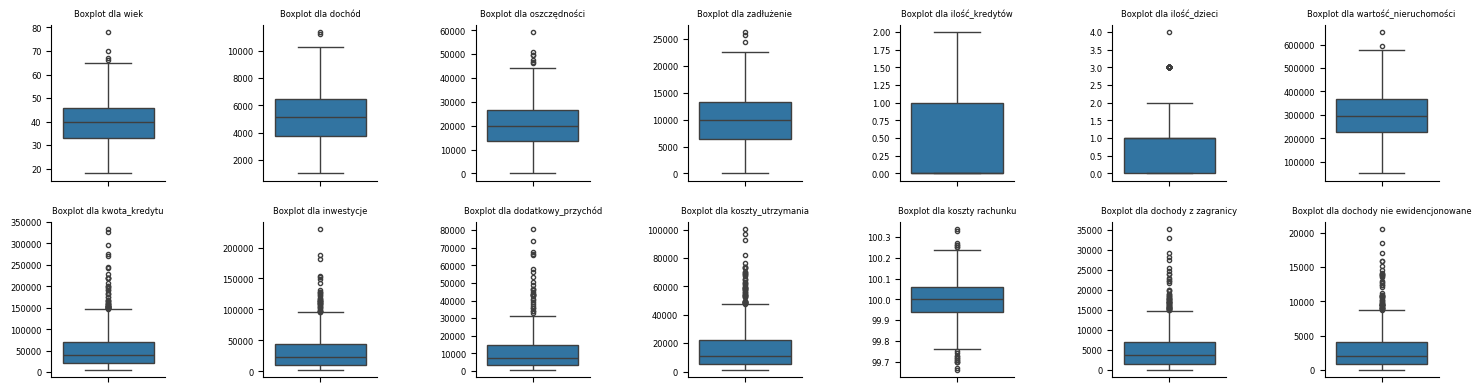

**Znaleziono 26 obserwacji odstających:**

### Wartości odstające przed transformacją

,wiek,dochód,oszczędności,zadłużenie,ilość_kredytów,ilość_dzieci,wartość_nieruchomości,kwota_kredytu,inwestycje,dodatkowy_przychód,koszty_utrzymania,koszty rachunku,dochody z zagranicy,dochody nie ewidencjonowane
0,44,7798.71,13248.22,460.96,0,0,188591.86,5487.39,41236.33,9972.89,7163.91,100.18,9376.0,12134
18,30,4359.31,26354.18,7744.21,0,1,285265.98,107967.37,5059.39,2762.26,4406.41,99.99,6536.0,12704
93,36,5103.89,8611.67,12098.05,1,2,212880.70,147894.01,12418.28,939.66,3889.66,99.97,3949.0,15100
121,30,7374.06,27846.04,6939.17,0,2,314775.59,8857.38,2425.39,26280.46,15684.08,100.02,1009.0,13796
173,43,4874.81,21517.58,13880.14,0,1,167950.66,40162.71,43848.54,4575.83,57742.29,100.09,11681.0,13733
199,28,7728.28,24878.72,12186.57,1,1,264175.56,65560.67,58321.88,4539.31,29364.17,100.03,1970.0,15806
209,78,8499.15,19992.91,12256.13,0,1,234025.14,67968.03,14363.64,4996.97,24935.95,99.96,125.0,7368
213,46,6789.85,15479.10,17616.19,0,1,169541.06,88361.44,23517.18,8099.94,6287.69,99.90,5154.0,13933
296,48,6838.15,24183.98,18381.97,0,1,207086.37,122160.82,31860.09,9855.34,14494.13,100.11,9240.0,12977
394,51,4269.36,19165.62,19862.71,1,0,209719.11,30884.95,30956.01,6304.47,2273.41,99.95,5017.0,13937


**Przekształcono wartości odstające metodą winsoryzacji:**

### Wartości odstające po transformacji

,wiek,dochód,oszczędności,zadłużenie,ilość_kredytów,ilość_dzieci,wartość_nieruchomości,kwota_kredytu,inwestycje,dodatkowy_przychód,koszty_utrzymania,koszty rachunku,dochody z zagranicy,dochody nie ewidencjonowane
0,44,7798.71,13248.22,1068.12,0,0,188591.86,7823.49,41236.33,9972.89,7163.91,100.16,9376.0,8933
18,30,4359.31,26354.18,7744.21,0,1,285265.98,107967.37,5059.39,2762.26,4406.41,99.99,6536.0,8933
93,36,5103.89,8611.67,12098.05,1,2,212880.70,147894.01,12418.28,939.66,3889.66,99.97,3949.0,8933
121,30,7374.06,27846.04,6939.17,0,2,314775.59,8857.38,3471.47,26280.46,15684.08,100.02,1009.0,8933
173,43,4874.81,21517.58,13880.14,0,1,167950.66,40162.71,43848.54,4575.83,48800.00,100.09,11681.0,8933
199,28,7728.28,24878.72,12186.57,1,1,264175.56,65560.67,58321.88,4539.31,29364.17,100.03,1970.0,8933
209,56,8390.10,19992.91,12256.13,0,1,234025.14,67968.03,14363.64,4996.97,24935.95,99.96,252.0,7368
213,46,6789.85,15479.10,17616.19,0,1,169541.06,88361.44,23517.18,8099.94,6287.69,99.90,5154.0,8933
296,48,6838.15,24183.98,18345.35,0,1,207086.37,122160.82,31860.09,9855.34,14494.13,100.11,9240.0,8933
394,51,4269.36,19165.62,18345.35,1,0,209719.11,30884.95,30956.01,6304.47,2273.41,99.95,5017.0,8933


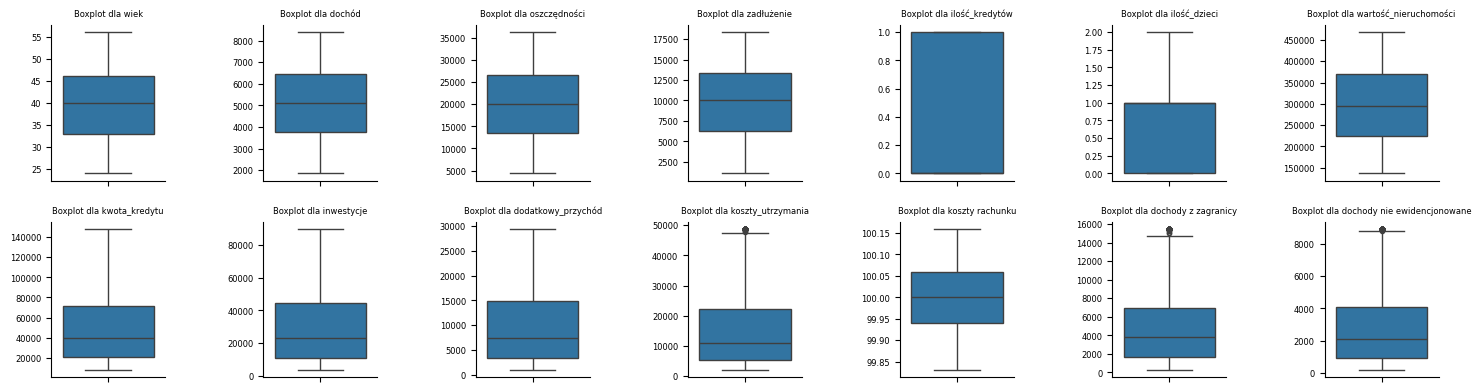

In [27]:

# ====================================================================
# Identyfikacja i obsługa wartości odstających
# ====================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
from scipy.stats import zscore
from scipy.stats.mstats import winsorize
from IPython.display import display, Markdown


display(Markdown('**Analiza wartości odstających:**'))
display(Markdown('- wartości odstające wykryte metodą (z_scores) > 3) zostaną przekształcone metodą winsoryzacji:'))

numeric_cols = X.select_dtypes(include=['number']).columns

# Tworzenie wykresów pudełkowych dla wszystkich zmiennych liczbowych
num_cols = len(numeric_cols)
fig, axes = plt.subplots(nrows=(num_cols // 7) + 1, ncols=min(7, num_cols), figsize=(15, 2 * ((num_cols // 7) + 1)))
axes = axes.flatten() if num_cols > 1 else [axes]
for i, column in enumerate(numeric_cols):
    sns.boxplot(y=X[column], ax=axes[i], flierprops={'marker': 'o', 'color': 'red', 'markersize': 3})
    axes[i].set_title(f"Boxplot dla {column}")
    axes[i].set_xlabel("")
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=6)
    ax.title.set_fontsize(6)
    axes[i].set_ylabel("")
    for ax in axes:
        ax.tick_params(axis='both', which='major', labelsize=6)
        ax.title.set_fontsize(6)
        ax.set_ylabel("")  # Remove y-axis label
        #ax.yaxis.set_visible(False)  # Hide y-axis ticks and labels
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        #ax.spines['left'].set_visible(False)
        #ax.spines['bottom'].set_visible(False)
plt.show()



# Obliczenie Z-score dla zmiennych liczbowych
numeric_cols = X.select_dtypes(include=['number']).columns
z_scores = X[numeric_cols].apply(zscore)

# Wykrywanie obserwacji odstających (|Z-score| > 3)
outliers_mask = (np.abs(z_scores) > 3).any(axis=1)
display(Markdown(f'**Znaleziono {outliers_mask.sum()} obserwacji odstających:**'))
# Tworzenie tabeli przed transformacją
outliers_before = X.loc[outliers_mask, numeric_cols]
display(Markdown("### Wartości odstające przed transformacją"))
display(outliers_before)




# Usuwanie lub transformacja wartości odstających
decision = "transform"  # Można zmienić na "remove"

if decision == "remove":
    X = X[~outliers_mask]
    y = y[~outliers_mask]
    print("Usunięto obserwacje odstające")

elif decision == "transform":
    for col in numeric_cols:
        X[col] = winsorize(X[col], limits=[0.05, 0.05])
    display(Markdown(f'**Przekształcono wartości odstające metodą winsoryzacji:**'))
    # Tworzenie tabeli po transformacji
    outliers_after = X.loc[outliers_mask, numeric_cols]
    display(Markdown("### Wartości odstające po transformacji"))
    display(outliers_after)
    

# Tworzenie wykresów pudełkowych dla wszystkich zmiennych liczbowych
num_cols = len(numeric_cols)
fig, axes = plt.subplots(nrows=(num_cols // 7) + 1, ncols=min(7, num_cols), figsize=(15, 2 * ((num_cols // 7) + 1)))
axes = axes.flatten() if num_cols > 1 else [axes]
for i, column in enumerate(numeric_cols):
    sns.boxplot(y=X[column], ax=axes[i], flierprops={'marker': 'o', 'color': 'red', 'markersize': 3})
    axes[i].set_title(f"Boxplot dla {column}")
    axes[i].set_xlabel("")
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=6)
    ax.title.set_fontsize(6)
    axes[i].set_ylabel("")
    for ax in axes:
        ax.tick_params(axis='both', which='major', labelsize=6)
        ax.title.set_fontsize(6)
        ax.set_ylabel("")  # Remove y-axis label
        #ax.yaxis.set_visible(False)  # Hide y-axis ticks and labels
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        #ax.spines['left'].set_visible(False)
        #ax.spines['bottom'].set_visible(False)
plt.show()


# Aktualizacja danych po zmianach
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)



#### 3.5 Identyfikacja zależności zmiennych numerycznych

**Identyfikacja korelacji zmiennych numerycznych:**

Macierz korelacji:


,wiek,dochód,oszczędności,zadłużenie,ilość_kredytów,ilość_dzieci,wartość_nieruchomości,kwota_kredytu,inwestycje,dodatkowy_przychód,koszty_utrzymania,koszty rachunku,liczba wizyt w oddziale,dochody z zagranicy,dochody nie ewidencjonowane,kredyt
wiek,1.000000,-0.046639,0.024964,-0.014288,-0.033285,-0.004130,-0.030030,-0.006264,-0.031703,0.055229,-0.011509,0.006703,0.051518,0.036673,0.034434,-0.006492
dochód,-0.046639,1.000000,-0.010178,-0.057793,-0.036383,0.024518,-0.004762,0.022782,0.008036,-0.003681,0.036732,-0.036670,0.054777,-0.022277,-0.012434,0.054433
oszczędności,0.024964,-0.010178,1.000000,0.028001,0.030572,-0.022237,-0.027681,0.000805,0.008326,-0.027316,-0.080645,-0.073243,-0.051948,0.029832,-0.006996,0.151617
zadłużenie,-0.014288,-0.057793,0.028001,1.000000,0.046840,0.035293,0.011309,0.014149,-0.040385,-0.027177,0.045472,-0.023470,0.009197,0.005628,0.040392,-0.219454
ilość_kredytów,-0.033285,-0.036383,0.030572,0.046840,1.000000,-0.050875,0.005212,0.008814,0.002883,0.017065,-0.036128,-0.017176,-0.067408,0.013275,-0.057005,-0.071738
ilość_dzieci,-0.004130,0.024518,-0.022237,0.035293,-0.050875,1.000000,0.019430,0.013273,-0.000255,0.024309,0.055334,0.012849,0.049479,0.015345,0.020415,0.013017
wartość_nieruchomości,-0.030030,-0.004762,-0.027681,0.011309,0.005212,0.019430,1.000000,0.035759,-0.033775,0.009160,0.020943,-0.029952,-0.013657,0.001931,-0.053165,0.006162
kwota_kredytu,-0.006264,0.022782,0.000805,0.014149,0.008814,0.013273,0.035759,1.000000,-0.060638,-0.040581,0.018862,-0.007033,-0.007249,-0.005624,-0.049049,-0.499861
inwestycje,-0.031703,0.008036,0.008326,-0.040385,0.002883,-0.000255,-0.033775,-0.060638,1.000000,-0.025145,0.008791,-0.034319,0.040481,-0.038507,-0.014695,0.181930
dodatkowy_przychód,0.055229,-0.003681,-0.027316,-0.027177,0.017065,0.024309,0.009160,-0.040581,-0.025145,1.000000,0.001901,-0.010524,0.030210,0.042244,0.008020,0.193804


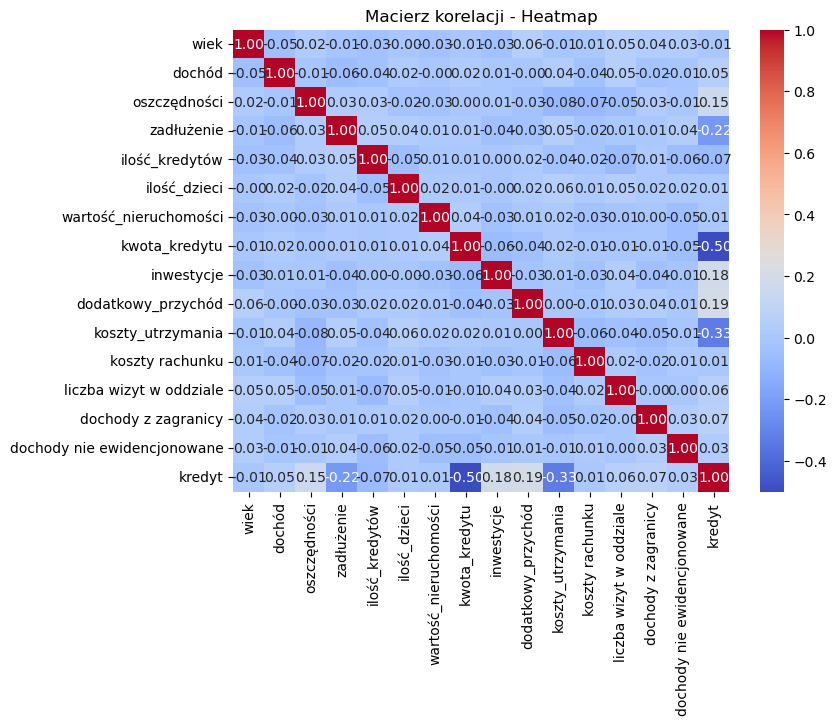

Brak zmiennych o korelacji powyżej progu 0.8.


**Podsumowanie po czyszczeniu danych :**

Ostateczny kształt danych: 1003 wierszy, 23 kolumn


In [28]:


# ====================================================================
# Identyfikacja korelacji zmiennych numerycznych
# ====================================================================

display(Markdown('**Identyfikacja korelacji zmiennych numerycznych:**'))

# Wybór tylko zmiennych numerycznych
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Obliczenie macierzy korelacji
corr_matrix = numeric_df.corr()

# Wyświetlenie macierzy korelacji
print("Macierz korelacji:")
display(corr_matrix)

# Wizualizacja macierzy korelacji
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Macierz korelacji - Heatmap")
plt.show()



# ====================================================================
# Identyfikacja skorelowanych zmiennych powyżej progu
# ====================================================================
threshold = 0.8  # Próg korelacji
high_corr_pairs = []

# Przeglądanie macierzy korelacji
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):  # Unikamy duplikatów (dolna trójkątna macierz)
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

# Wyświetlenie listy skorelowanych zmiennych
if high_corr_pairs:
    display(Markdown("### Zmienne o korelacji powyżej progu 0.8:"))
    for var1, var2, corr in high_corr_pairs:
        print(f"- {var1} i {var2}: korelacja {corr:.2f}")
else:
    print("Brak zmiennych o korelacji powyżej progu 0.8.")



# ====================================================================
# 4. Aktualizacja analiz po czyszczeniu danych
# ====================================================================
display(Markdown('**Podsumowanie po czyszczeniu danych :**'))

print(f"Ostateczny kształt danych: {X.shape[0]} wierszy, {X.shape[1]} kolumn")



#### 3.6 Identyfikacja zależności zmiennych nominalnych

,Zmienna kategorialna,Liczba kategorii,Chi2,P-wartość,V Cramera,Liczność kategorii
0,czy_karta_kredytowa,2,0.501220,0.478964,0.022366,"{'tak': 532, 'nie': 470}"
1,czy_korzysta_z_aplikacji,2,1.280580,0.257791,0.035732,"{'Nie': 517, 'Tak': 486}"
2,wykształcenie,4,3.613424,0.306347,0.060082,"{'zawodowe': 266, 'wyższe': 260, 'średnie': 242, 'podstawowe': 233}"
3,sytuacja_mieszkaniowa,3,0.308581,0.857023,0.017540,"{'wynajem': 346, 'mieszkanie z rodzicami': 329, 'własne': 328}"
4,forma_wynagrodzenia,3,0.500095,0.778764,0.022329,"{'za wykonanie': 355, 'tygodniowe': 346, 'miesięczne': 302}"
5,źródło_dochodu,10,12.192634,0.202666,0.110365,"{'Dochody z działalności gospodarczej': 180, 'Emerytura': 174, 'Renta': 170, 'Wynagrodzenie etatowe': 162, 'Wynagrodzenie za zlecenie': 140, 'Stypendium': 39, 'Dochody z najmu': 36, 'Wynagrodzenie za dzieło': 35, 'Dochody kapitałowe': 34, 'Inne źródło dochodu': 31}"
6,typ_zabezpieczenia,3,8.457419,0.014571,0.091827,"{'hipoteka': 344, 'gwarancja bankowa': 332, 'poręczenie': 327}"
7,czy_aktywny_online,2,0.126880,0.721689,0.011247,"{'Tak': 505, 'Nie': 498}"
8,czy_ubezpieczenie,2,9.978987,0.001583,0.099845,"{'tak': 512, 'nie': 489}"


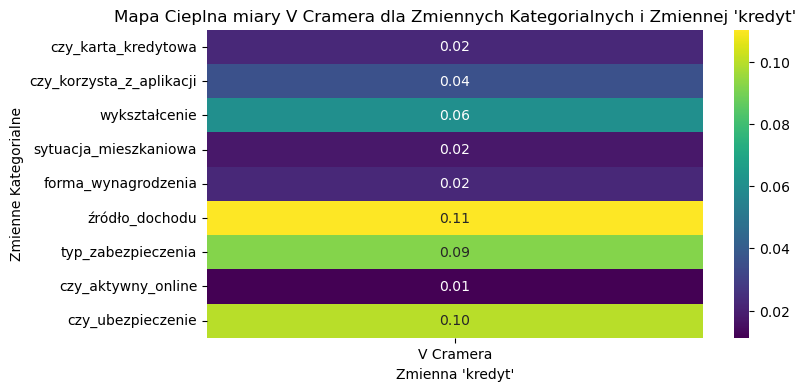

In [40]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from sklearn.preprocessing import OrdinalEncoder
import matplotlib.pyplot as plt
import seaborn as sns

def cramers_v(confusion_matrix):

    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum()
    min_dim = min(confusion_matrix.shape) - 1
    # Zapobiega dzieleniu przez zero
    if n == 0 or min_dim == 0:
        return 0.0
    else:
        return np.sqrt((chi2 / n) / min_dim)

def analiza_korelacji_kredyt_kategoria(df, zmienne_kategorialne, kredyt_zmienna='kredyt'):

    wyniki = []
    for zmienna in zmienne_kategorialne:
        # 1. Obliczenie tabeli kontyngencji
        tab_kont = pd.crosstab(df[zmienna], df[kredyt_zmienna])

        # 2. Wykonanie testu chi-kwadrat
        chi2, p, dof, oczekiwane = chi2_contingency(tab_kont)

        # 3. Obliczenie V Cramera
        v_cramer = cramers_v(tab_kont.values) # Dodano obliczenie V Cramera

        # 4. Obliczenie średniego kredytu dla każdej kategorii
        sredni_kredyt = df.groupby(zmienna)[kredyt_zmienna].mean()
        licznosc_kategorii = df[zmienna].value_counts()

        # Dodanie wyników do listy
        wyniki.append({
            'Zmienna kategorialna': zmienna,
            'Liczba kategorii': len(tab_kont),
            'Chi2': chi2,
            'P-wartość': p,
            'V Cramera': v_cramer, # Dodano V Cramera do wyników
            #'Średni kredyt dla kategorii': sredni_kredyt.to_dict(), # Usunięto kolumnę z wynikami
            'Liczność kategorii': licznosc_kategorii.to_dict()
        })

    # Konwersja wyników na DataFrame
    wyniki_df = pd.DataFrame(wyniki)
    return wyniki_df

def wizualizacja_korelacji_kredyt_kategoria(df, wyniki_df, kredyt_zmienna='kredyt'):

    # Przygotowanie danych do mapy cieplnej
    cramer_matrix = pd.DataFrame(index=wyniki_df['Zmienna kategorialna'], columns=['V Cramera'])
    for index, row in wyniki_df.iterrows():
        cramer_matrix.loc[row['Zmienna kategorialna'], 'V Cramera'] = row['V Cramera']

    # Konwersja kolumny 'V Cramera' na typ numeryczny
    cramer_matrix['V Cramera'] = pd.to_numeric(cramer_matrix['V Cramera'], errors='coerce')

    # Mapa cieplna
    plt.figure(figsize=(8, 4))
    sns.heatmap(cramer_matrix, annot=True, cmap='viridis', fmt=".2f")
    plt.title("Mapa Cieplna miary V Cramera dla Zmiennych Kategorialnych i Zmiennej 'kredyt'")
    plt.xlabel("Zmienna 'kredyt'")
    plt.ylabel("Zmienne Kategorialne")
    plt.show()


zmienne_kategorialne = ['czy_karta_kredytowa', 'czy_korzysta_z_aplikacji', 'wykształcenie', 'sytuacja_mieszkaniowa', 'forma_wynagrodzenia', 'źródło_dochodu', 'typ_zabezpieczenia', 'czy_aktywny_online', 'czy_ubezpieczenie']
wyniki_analizy = analiza_korelacji_kredyt_kategoria(df, zmienne_kategorialne)
display(wyniki_analizy)
wizualizacja_korelacji_kredyt_kategoria(df, wyniki_analizy)


# III. Tworzenia modelu klasyfikacyjnego

### 1.Wydzielenie ze zbioru zmienych objaśniających [X] oraz zmiennej celu [Y]

> Podział zbioru danych na:

- Zmienną docelową (y) – zawierającą wartości kolumny 'kredyt', którą chcemy przewidywać.

- Zmiennie objaśniające (X) – czyli wszystkie pozostałe kolumny oprócz 'kredyt', które będą używane jako cechy wejściowe do modelu predykcyjnego.

In [41]:

# Wydzielenie X (zmienne objaśniające) i y (zmienna docelowa)
X = df.drop('kredyt', axis=1)
y = df['kredyt']



# Tworzenie DataFrame z nazwami zmiennych predykcyjnych i zmiennej celu
variables_info = {
    'Zmienne predykcyjne': X.columns.tolist(),
    'Zmienna celu': [y.name]
}
variables_df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in variables_info.items()]))
variables_df = variables_df.fillna('')  # Zamiana NaN na pusty wiersz
display(Markdown('**Nazwy zmiennych predykcyjnych i zmiennej celu:**'))
display(variables_df)




**Nazwy zmiennych predykcyjnych i zmiennej celu:**

,Zmienne predykcyjne,Zmienna celu
0,wiek,kredyt
1,dochód,
2,oszczędności,
3,zadłużenie,
4,ilość_kredytów,
5,ilość_dzieci,
6,wartość_nieruchomości,
7,kwota_kredytu,
8,inwestycje,
9,dodatkowy_przychód,


### 2.Podział danych na zbiory treningowy,  testowy

> Podział danych na zbiór treningowy i testowy jest kluczowy w uczeniu maszynowym, ponieważ pozwala ocenić rzeczywistą skuteczność modelu na nowych, niewidzianych wcześniej danych.
- Uniknięcie przeuczenia (overfittingu) – trenując model tylko na części danych, możemy ocenić jego jakość na niezależnym zbiorze testowym.
- Poprawna ocena modelu – zbiór testowy symuluje nowe, nieznane dane i pozwala sprawdzić, jak model generalizuje.
- Zachowanie proporcji klas (stratify=y) – zapewnia realistyczne warunki dla algorytmu uczenia maszynowego, szczególnie ważne przy niezrównoważonych klasach.



In [42]:


# ====================================================================
# 2. Podział danych na zbiory treningowy,  testowy
# ====================================================================


# Podział danych na zbiory treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y, shuffle=True)


# Tworzenie słownika z rozmiarami zbiorów danych
shape_dict = {
    "Dane": ["X - zmienna objaśniacjąca (cały zbiór)", "y - zmienna celu  (cały zbiór)", "X_train", "y_train", "X_test", "y_test"],
    "Rozmiar": [X.shape, y.shape, X_train.shape, y_train.shape, X_test.shape, y_test.shape],
}

print()
# Tworzenie DataFrame z rozmiarami zbiorów danych
shape_df = pd.DataFrame(shape_dict)
# Wyświetlenie DataFrame z rozmiarami zbiorów danych
print("Rozmiary zbiorów danych:")
display(shape_df)




# Tworzenie słownika z proporcjami zmiennej docelowej w zbiorach danych
prop_y = {
    'Struktura danych "y_train"': y_train.value_counts(normalize=True) * 100,
    'Struktura danych "y_test"': y_test.value_counts(normalize=True) * 100,
}
print()
# Tworzenie DataFrame z proporcjami zmiennej docelowej
proporcje_y = pd.DataFrame(prop_y)
# Wyświetlenie DataFrame z proporcjami zmiennej docelowej, zaokrąglonymi do dwóch miejsc po przecinku
print("Proporcje zmiennej docelowej w zbiorach danych:")
display(proporcje_y.round(2))
print()
# Obliczanie struktury danych
data_structure_info = {
    'Zbiór danych': ['X_train', 'X_test'],
    'Procent danych': [
        (X_train.shape[0] / X.shape[0]) * 100,
        (X_test.shape[0] / X.shape[0]) * 100,
    ],
}

print()


import altair as alt
import pandas as pd

# Tworzenie DataFrame
counts = y_train.value_counts().reset_index()
counts.columns = ['Klasa', 'Liczność']
counts['Procent'] = counts['Liczność'] / counts['Liczność'].sum() * 100

# Tworzenie wykresu
chart = (
    alt.Chart(counts)
    .mark_bar()
    .encode(
        x=alt.X('Klasa:N', title='Klasa'),
        y=alt.Y('Liczność:Q', title='Liczność'),
        color=alt.Color('Klasa:N', scale=alt.Scale(scheme='set2')),
        tooltip=['Klasa', 'Liczność', 'Procent']
    )
)

# Dodanie wartości procentowych
text = (
    alt.Chart(counts)
    .mark_text(dy=-10)
    .encode(
        x=alt.X('Klasa:N'),
        y=alt.Y('Liczność:Q'),
        text=alt.Text('Procent:Q', format='.1f')
    )
)

# Wyświetlenie wykresu
(chart + text).properties(title='Rozkład klas w zbiorze treningowym', width=500, height=200).interactive()





Rozmiary zbiorów danych:


,Dane,Rozmiar
0,X - zmienna objaśniacjąca (cały zbiór),"(1003, 24)"
1,y - zmienna celu (cały zbiór),"(1003,)"
2,X_train,"(802, 24)"
3,y_train,"(802,)"
4,X_test,"(201, 24)"
5,y_test,"(201,)"



Proporcje zmiennej docelowej w zbiorach danych:


,"Struktura danych ""y_train""","Struktura danych ""y_test"""
kredyt,,
0,52.0,51.74
1,48.0,48.26


alt.LayerChart(...)

### 3.Preprocesing danych

#### 3.1. Utworzenie struktury przepływ przekształceń

> Przekształcanie danych poprzez imputację braków, kodowanie cech kategorycznych, skalowanie, binaryzację, grupowanie wieku, transformację zmiennych skośnych oraz tworzenie transformerów, zapewni kompleksowe przygotowanie danych do modelowania.

In [43]:


# ====================================================================
# 3. Przetwarzanie danych
# ====================================================================


import pandas as pd

# Definiujemy dane
data = [
    ('czy_karta_kredytowa', 'binarna (kategoryczna)', 'Kodowanie wartości na 0 (Nie) i 1 (Tak)', 
     'Binarizer', 'SimpleImputer (most_frequent)'),
    ('czy_ubezpieczenie', 'binarna (kategoryczna)', 'Kodowanie wartości na 0 (Nie) i 1 (Tak)', 
     'Binarizer', 'SimpleImputer (most_frequent)'),
    ('czy_aktywny_online', 'binarna (kategoryczna)', 'Kodowanie wartości na 0 (Nie) i 1 (Tak)', 
     'Binarizer', 'SimpleImputer (most_frequent)'),
    ('czy_korzysta_z_aplikacji', 'binarna (kategoryczna)', 'Kodowanie wartości na 0 (Nie) i 1 (Tak)', 
     'Binarizer', 'SimpleImputer (most_frequent)'),
    ('wykształcenie', 'porządkowa (kategoryczna)', 
     'Przekształcenie kategorii na wartości liczbowe według hierarchii: podstawowe < zawodowe < średnie < wyższe', 
     'OrdinalEncoder', 'SimpleImputer (most_frequent)'),
    ('typ_zabezpieczenia', 'nominalna (kategoryczna)', 'Zamiana kategorii na zestaw zmiennych 0/1 (one-hot encoding)', 
     'OneHotEncoder', 'SimpleImputer (most_frequent)'),
    ('sytuacja_mieszkaniowa', 'nominalna (kategoryczna)', 'Zamiana kategorii na zestaw zmiennych 0/1 (one-hot encoding)', 
     'OneHotEncoder', 'SimpleImputer (most_frequent)'),
    ('forma_wynagrodzenia', 'nominalna (kategoryczna)', 'Zamiana kategorii na zestaw zmiennych 0/1 (one-hot encoding)', 
     'OneHotEncoder', 'SimpleImputer (most_frequent)'),
    ('ilość_kredytów', 'numeryczna', 'Standaryzacja wartości do rozkładu N(0,1)', 
     'StandardScaler', 'SimpleImputer (mean)'),
    ('liczba wizyt w oddziale', 'numeryczna', 'Standaryzacja wartości do rozkładu N(0,1)', 
     'StandardScaler', 'SimpleImputer (mean)'),
    ('koszty rachunku', 'numeryczna', 'Standaryzacja wartości do rozkładu N(0,1)', 
     'StandardScaler', 'SimpleImputer (mean)'),

    ('zadłużenie', 'numeryczna', 'Standaryzacja wartości do rozkładu N(0,1)', 
     'StandardScaler', 'SimpleImputer (mean)'),

    ('oszczędności', 'numeryczna', 'Standaryzacja wartości do rozkładu N(0,1)', 
     'StandardScaler', 'SimpleImputer (mean)'),

    ('wartość_nieruchomości', 'numeryczna', 'Standaryzacja wartości do rozkładu N(0,1)', 
     'StandardScaler', 'SimpleImputer (mean)'),

    ('dochody nie ewidencjonowane', 'binarna (kategoryczna)', 'Binarizacja wartości', 
     'Binarizer', 'SimpleImputer (most_frequent)'),

    ('źródło_dochodu', 'nominalna (kategoryczna)', 'Transformacja rzadkich wartości', 
     'Custom Transformer', 'SimpleImputer (most_frequent)'),

    ('wiek', 'numeryczna (kategoryczna)', 'Podział na przedziały wiekowe (14-22, 23-39, 40-64, >65)', 
     'pd.cut()', 'SimpleImputer (most_frequent)'),

    ('dochód', 'numeryczna', 'Obliczenie dochodu na osobę (dochód/liczba osób)', 
     'Custom Transformer: DochodNaOsobe', 'SimpleImputer (mean)'),

    ('ilość_dzieci', 'numeryczna', 'Wykorzystanie w obliczeniach dochodu na osobę', 
     'Custom Transformer: DochodNaOsobe', 'SimpleImputer (mean)'),

    ('kwota_kredytu', 'numeryczna', 'Obliczenie stosunku kwoty kredytu do wartości nieruchomości', 
     'Custom Transformer: StosunekKredytuDoNieruchomosci', 'SimpleImputer (mean)'),

    ('koszty_utrzymania', 'numeryczna', 'Standaryzacja wartości do rozkładu N(0,1)', 
     'StandardScaler', 'SimpleImputer (mean)'),

    ('inwestycje', 'numeryczna', 'Standaryzacja wartości do rozkładu N(0,1)', 
     'StandardScaler', 'SimpleImputer (mean)'),

    ('dodatkowy_przychód', 'numeryczna', 'Standaryzacja wartości do rozkładu N(0,1)', 
     'StandardScaler', 'SimpleImputer (mean)')
]

# Tworzenie DataFrame połączoną kolumną 'typ zmiennej' i bez 'Pipeline'
df = pd.DataFrame(data, columns=[
    'nazwa zmiennej', 'typ zmiennej', 'rodzaj przekształcenia', 
    'funkcja w Pythonie użyta do przekształcenia', 'imputacja braków'
])

# Ustawienie opcji wyświetlania, aby zawijać długie teksty
pd.set_option('display.max_colwidth', None)



print("Preprocesing danych - Zestawienie dokonanych przekształceń na danych:")

# Wyświetlenie tabeli
display(df)



Preprocesing danych - Zestawienie dokonanych przekształceń na danych:


,nazwa zmiennej,typ zmiennej,rodzaj przekształcenia,funkcja w Pythonie użyta do przekształcenia,imputacja braków
0,czy_karta_kredytowa,binarna (kategoryczna),Kodowanie wartości na 0 (Nie) i 1 (Tak),Binarizer,SimpleImputer (most_frequent)
1,czy_ubezpieczenie,binarna (kategoryczna),Kodowanie wartości na 0 (Nie) i 1 (Tak),Binarizer,SimpleImputer (most_frequent)
2,czy_aktywny_online,binarna (kategoryczna),Kodowanie wartości na 0 (Nie) i 1 (Tak),Binarizer,SimpleImputer (most_frequent)
3,czy_korzysta_z_aplikacji,binarna (kategoryczna),Kodowanie wartości na 0 (Nie) i 1 (Tak),Binarizer,SimpleImputer (most_frequent)
4,wykształcenie,porządkowa (kategoryczna),Przekształcenie kategorii na wartości liczbowe według hierarchii: podstawowe < zawodowe < średnie < wyższe,OrdinalEncoder,SimpleImputer (most_frequent)
5,typ_zabezpieczenia,nominalna (kategoryczna),Zamiana kategorii na zestaw zmiennych 0/1 (one-hot encoding),OneHotEncoder,SimpleImputer (most_frequent)
6,sytuacja_mieszkaniowa,nominalna (kategoryczna),Zamiana kategorii na zestaw zmiennych 0/1 (one-hot encoding),OneHotEncoder,SimpleImputer (most_frequent)
7,forma_wynagrodzenia,nominalna (kategoryczna),Zamiana kategorii na zestaw zmiennych 0/1 (one-hot encoding),OneHotEncoder,SimpleImputer (most_frequent)
8,ilość_kredytów,numeryczna,"Standaryzacja wartości do rozkładu N(0,1)",StandardScaler,SimpleImputer (mean)
9,liczba wizyt w oddziale,numeryczna,"Standaryzacja wartości do rozkładu N(0,1)",StandardScaler,SimpleImputer (mean)


Cel: Przygotowanie danych do analizy poprzez transformację różnych typów zmiennych do formatu numerycznego, co jest wymagane przez większość algorytmów uczenia maszynowego

In [44]:

# przypisanie zmiennych do kategorii 

# binary_features = ['czy_karta_kredytowa', 'czy_ubezpieczenie', 'czy_aktywny_online', 'czy_korzysta_z_aplikacji']
# ordinal_features = ['wykształcenie']
# onehot_features = ['typ_zabezpieczenia', 'sytuacja_mieszkaniowa', 'forma_wynagrodzenia']
# binarize_feature = ['dochody nie ewidencjonowane']
# ohe_rare_feature = ['źródło_dochodu']
# numeric_features = ['ilość_kredytów', 'liczba wizyt w oddziale', 'koszty rachunku','zadłużenie', 'oszczędności','wartość_nieruchomości']
# income_cols = ['dochód', 'ilość_dzieci']
# skewed_features = ['dodatkowy_przychód', 'dochody z zagranicy', 'kwota_kredytu', 'koszty_utrzymania',   'inwestycje' ]



# Funkcja do grupowania wiekowego
def create_age_groups(X):
    bins = [14, 23, 40, 65, 105]
    labels = ['14-22', '23-39', '40-64', '> 65']
    return pd.DataFrame(pd.cut(X['wiek'], bins=bins, labels=labels))



# Klasa transformera dochodu na osobę
class IncomePerPerson(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.imputer = SimpleImputer(strategy='mean')
        self.scaler = StandardScaler()
        self.power_transformer = PowerTransformer(method='yeo-johnson', standardize=True)

    def fit(self, X, y=None):
        X_imputed = self.imputer.fit_transform(X)
        X_temp = pd.DataFrame(X_imputed, columns=['dochód', 'ilość_dzieci'])
        X_temp['dochód_na_osobę'] = X_temp['dochód'] / X_temp['ilość_dzieci'].replace(0, np.nan)
        self.scaler.fit(X_temp[['dochód_na_osobę']].fillna(0))
        self.power_transformer.fit(X_temp[['dochód_na_osobę']].fillna(0))
        return self

    def transform(self, X):
        X_imputed = self.imputer.transform(X)
        X_temp = pd.DataFrame(X_imputed, columns=['dochód', 'ilość_dzieci'])
        X_temp['dochód_na_osobę'] = X_temp['dochód'] / X_temp['ilość_dzieci'].replace(0, np.nan)
        X_temp['dochód_na_osobę'].fillna(0, inplace=True)
        X_temp['dochód_na_osobę'] = self.power_transformer.transform(X_temp[['dochód_na_osobę']])
        return self.scaler.transform(X_temp[['dochód_na_osobę']])
    

# Tworzenie pipeline'ów
binary_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OrdinalEncoder(),
    Binarizer(threshold=0.5)
)
ordinal_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OrdinalEncoder(categories=[['podstawowe', 'zawodowe', 'średnie', 'wyższe']], dtype=int)
)

ohe_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore', sparse_output=False)
)

ohe_rare_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='infrequent_if_exist', sparse_output=False, min_frequency=0.05, dtype=int)
)
numeric_pipeline = make_pipeline(
    SimpleImputer(strategy='mean'),
    StandardScaler()
)

binarizer_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    Binarizer(threshold=1500)
)
skewed_pipeline = make_pipeline(
    SimpleImputer(strategy='mean'),
    PowerTransformer(method='yeo-johnson', standardize=True)
)
income_per_person_pipeline = make_pipeline(
    IncomePerPerson()
)

age_groups_pipeline = make_pipeline(
    FunctionTransformer(create_age_groups),
    OrdinalEncoder(categories=[['14-22', '23-39', '40-64', '> 65']], dtype=int,)
)


### 5. Pełny przepływ modelu

> Tworzenie pełnego pipeline’u z dla róznych modeli klasyfikacyjnych
- preprocesorem
- selektorem
- klassyfikatorem


#### 5.1. Tworzenie preprocesora

In [46]:

# Łączenie pipeline'ów w ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('binary', binary_pipeline, ['czy_karta_kredytowa', 'czy_ubezpieczenie', 'czy_aktywny_online', 'czy_korzysta_z_aplikacji']),
        ('ordinal', ordinal_pipeline, ['wykształcenie']),
        ('onehot', ohe_pipeline, ['typ_zabezpieczenia', 'sytuacja_mieszkaniowa', 'forma_wynagrodzenia']),
        ('numeric', numeric_pipeline, ['ilość_kredytów', 'koszty rachunku', 'zadłużenie', 'oszczędności', 'wartość_nieruchomości']),
        ('binarize', binarizer_pipeline, ['dochody nie ewidencjonowane']),
        ('oherare', ohe_rare_pipeline, ['źródło_dochodu']),
        ('wiek_grupy', age_groups_pipeline, ['wiek']),
        ('dochod_na_osobe', income_per_person_pipeline, ['dochód', 'ilość_dzieci']),
        ('skewed', skewed_pipeline, ['dodatkowy_przychód', 'dochody z zagranicy', 'kwota_kredytu', 'koszty_utrzymania', 'inwestycje'])
    ],
    remainder='passthrough'
)

# Tworzenie DataFrame z elementami preprocesora
preprocessor_elements = []

for name, pipeline, features in preprocessor.transformers:
    if name != 'remainder':  # Pomijamy kolumny, które są przekazywane bez zmian
        for step_name, step in pipeline.steps:
            preprocessor_elements.append({
                'Nazwa transformacji': name,
                'Funkcja': step_name,
                'Typ transformacji': type(step).__name__,
                'Zmienione cechy': ', '.join(features)
            })

preprocessor_df = pd.DataFrame(preprocessor_elements)
# Tworzenie DataFrame z nazwami kroków i nazwami pipeline'ów
column_transformer_steps = []

for name, pipeline, features in preprocessor.transformers:
    if name != 'remainder':  # Pomijamy kolumny przekazywane bez zmian
        column_transformer_steps.append({
            'Nazwa transformacji': name,
            'Kroki w pipeline': ' -> '.join([step_name for step_name, _ in pipeline.steps])
        })

steps_df = pd.DataFrame(column_transformer_steps)

# Wyświetlenie DataFrame
display(Markdown('**Kroki w ColumnTransformer:**'))
display(steps_df)
display(Markdown('**Elementy preprocesora:**'))
display(preprocessor_df)
print()


# Transformacja danych przy użyciu preprocesora
X_transformed = preprocessor.fit_transform(X_train)

print("Dane po przekształceniu:")
display(X_transformed.head().T)

print()
# # Transformacja danych przy użyciu preprocesora
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test) # Transformacja danych testowych
print()

print("Diagram przepływu przekształceń:")

display(preprocessor)


**Kroki w ColumnTransformer:**

,Nazwa transformacji,Kroki w pipeline
0,binary,simpleimputer -> ordinalencoder -> binarizer
1,ordinal,simpleimputer -> ordinalencoder
2,onehot,simpleimputer -> onehotencoder
3,numeric,simpleimputer -> standardscaler
4,binarize,simpleimputer -> binarizer
5,oherare,simpleimputer -> onehotencoder
6,wiek_grupy,functiontransformer -> ordinalencoder
7,dochod_na_osobe,incomeperperson
8,skewed,simpleimputer -> powertransformer


**Elementy preprocesora:**

,Nazwa transformacji,Funkcja,Typ transformacji,Zmienione cechy
0,binary,simpleimputer,SimpleImputer,"czy_karta_kredytowa, czy_ubezpieczenie, czy_aktywny_online, czy_korzysta_z_aplikacji"
1,binary,ordinalencoder,OrdinalEncoder,"czy_karta_kredytowa, czy_ubezpieczenie, czy_aktywny_online, czy_korzysta_z_aplikacji"
2,binary,binarizer,Binarizer,"czy_karta_kredytowa, czy_ubezpieczenie, czy_aktywny_online, czy_korzysta_z_aplikacji"
3,ordinal,simpleimputer,SimpleImputer,wykształcenie
4,ordinal,ordinalencoder,OrdinalEncoder,wykształcenie
5,onehot,simpleimputer,SimpleImputer,"typ_zabezpieczenia, sytuacja_mieszkaniowa, forma_wynagrodzenia"
6,onehot,onehotencoder,OneHotEncoder,"typ_zabezpieczenia, sytuacja_mieszkaniowa, forma_wynagrodzenia"
7,numeric,simpleimputer,SimpleImputer,"ilość_kredytów, koszty rachunku, zadłużenie, oszczędności, wartość_nieruchomości"
8,numeric,standardscaler,StandardScaler,"ilość_kredytów, koszty rachunku, zadłużenie, oszczędności, wartość_nieruchomości"
9,binarize,simpleimputer,SimpleImputer,dochody nie ewidencjonowane



Dane po przekształceniu:


,913,365,460,581,776
binary__czy_karta_kredytowa,1.000000,1.000000,0.000000,0.000000,1.000000
binary__czy_ubezpieczenie,0.000000,1.000000,0.000000,1.000000,1.000000
binary__czy_aktywny_online,0.000000,0.000000,0.000000,0.000000,0.000000
binary__czy_korzysta_z_aplikacji,1.000000,0.000000,0.000000,0.000000,1.000000
ordinal__wykształcenie,2.000000,3.000000,3.000000,3.000000,3.000000
onehot__typ_zabezpieczenia_gwarancja bankowa,1.000000,0.000000,1.000000,0.000000,1.000000
onehot__typ_zabezpieczenia_hipoteka,0.000000,1.000000,0.000000,1.000000,0.000000
onehot__typ_zabezpieczenia_poręczenie,0.000000,0.000000,0.000000,0.000000,0.000000
onehot__sytuacja_mieszkaniowa_mieszkanie z rodzicami,0.000000,0.000000,0.000000,0.000000,0.000000
onehot__sytuacja_mieszkaniowa_wynajem,0.000000,0.000000,0.000000,1.000000,0.000000




Diagram przepływu przekształceń:


ColumnTransformer(remainder='passthrough',
                  transformers=[('binary',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder()),
                                                 ('binarizer',
                                                  Binarizer(threshold=0.5))]),
                                 ['czy_karta_kredytowa', 'czy_ubezpieczenie',
                                  'czy_aktywny_online',
                                  'czy_korzysta_z_aplikacji']),
                                ('ordinal',
                                 Pipeline(steps=[('simpleimput...
                                                                              '23-39',
                                                                              '40-64',
                                                                              '> '
                                                                              '65']],
                                                                 dtype=<class 'int'>))]),
                                 ['wiek']),
                                ('dochod_na_osobe',
                                 Pipeline(steps=[('incomeperperson',
                                                  IncomePerPerson())]),
                                 ['dochód', 'ilość_dzieci']),
                                ('skewed',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer()),
                                                 ('powertransformer',
                                                  PowerTransformer())]),
                                 ['dodatkowy_przychód', 'dochody z zagranicy',
                                  'kwota_kredytu', 'koszty_utrzymania',
                                  'inwestycje'])])

### 4.Selekcja danych



#### 4.1. Ważnosć cech - wg modelu Random Forest

,Feature,Importance
30,skewed__kwota_kredytu,0.284308
31,skewed__koszty_utrzymania,0.129690
16,numeric__zadłużenie,0.069330
28,skewed__dodatkowy_przychód,0.062352
17,numeric__oszczędności,0.052736
32,skewed__inwestycje,0.048836
29,skewed__dochody z zagranicy,0.043522
33,remainder__liczba wizyt w oddziale,0.039338
18,numeric__wartość_nieruchomości,0.039319
27,dochod_na_osobe__dochód_na_osobę,0.039256


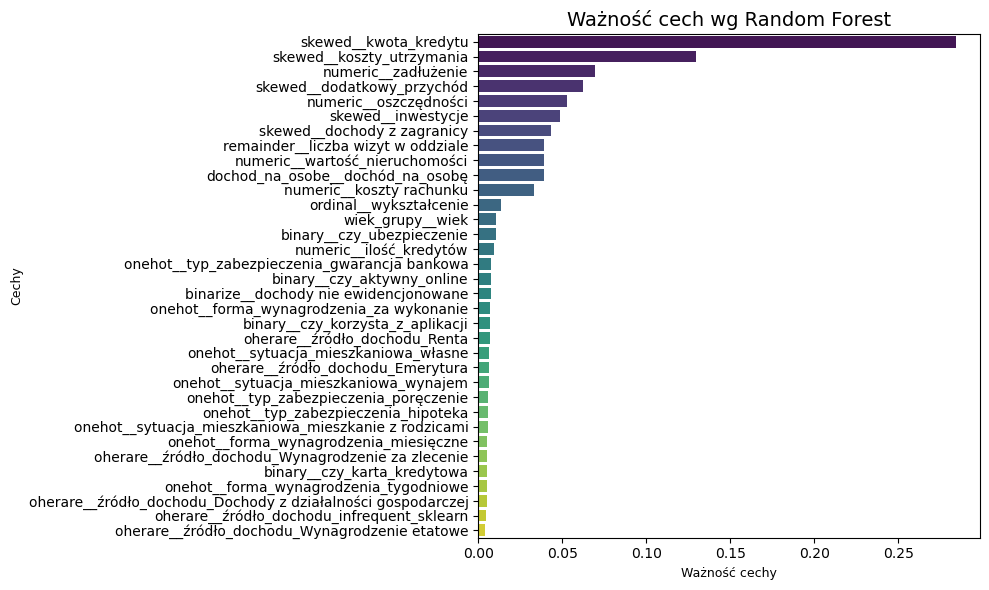

In [48]:

# ====================================================================
# SELEKCJA CECH (WAŻNOŚĆ CECH RANDOM FOREST)
# ====================================================================

# Inicjalizacja klasyfikatora Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Utworzenie obiektu SelectFromModel
feature_selection_rf = SelectFromModel(rf, threshold= 0.005)  # Możesz dostosować próg



# Selekcja cech na przetransformowanych danych
X_train_selected_rf = feature_selection_rf.fit_transform(X_train_transformed, y_train)
X_test_selected_rf = feature_selection_rf.transform(X_test_transformed)

# Pobranie ważności cech z modelu Random Forest
feature_importances = rf.fit(X_train_transformed, y_train).feature_importances_

# Tworzenie DataFrame z cechami i ich ważnością
feature_importance_df = pd.DataFrame({
    'Feature': X_train_transformed.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Wyświetlenie posortowanego DataFrame
display(feature_importance_df)

features=20  # Domyślna wartość, zmieniana w siatce hiperparametrów
#     ))
# ])
# Wizualizacja ważności cech
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance_df['Importance'], y=feature_importance_df['Feature'], palette='viridis')
plt.title('Ważność cech wg Random Forest', fontsize=14)
plt.xlabel('Ważność cechy', fontsize=9)
plt.ylabel('Cechy', fontsize=9)
plt.tight_layout()
plt.show()


#### 4.2. Ważnosć cech - wg mutual information

,Feature,Importance
30,skewed__kwota_kredytu,0.218761
31,skewed__koszty_utrzymania,0.086960
6,onehot__typ_zabezpieczenia_hipoteka,0.035686
5,onehot__typ_zabezpieczenia_gwarancja bankowa,0.030142
32,skewed__inwestycje,0.023819
24,oherare__źródło_dochodu_Wynagrodzenie za zlecenie,0.021098
22,oherare__źródło_dochodu_Renta,0.020379
23,oherare__źródło_dochodu_Wynagrodzenie etatowe,0.019366
14,numeric__ilość_kredytów,0.018595
8,onehot__sytuacja_mieszkaniowa_mieszkanie z rodzicami,0.018120


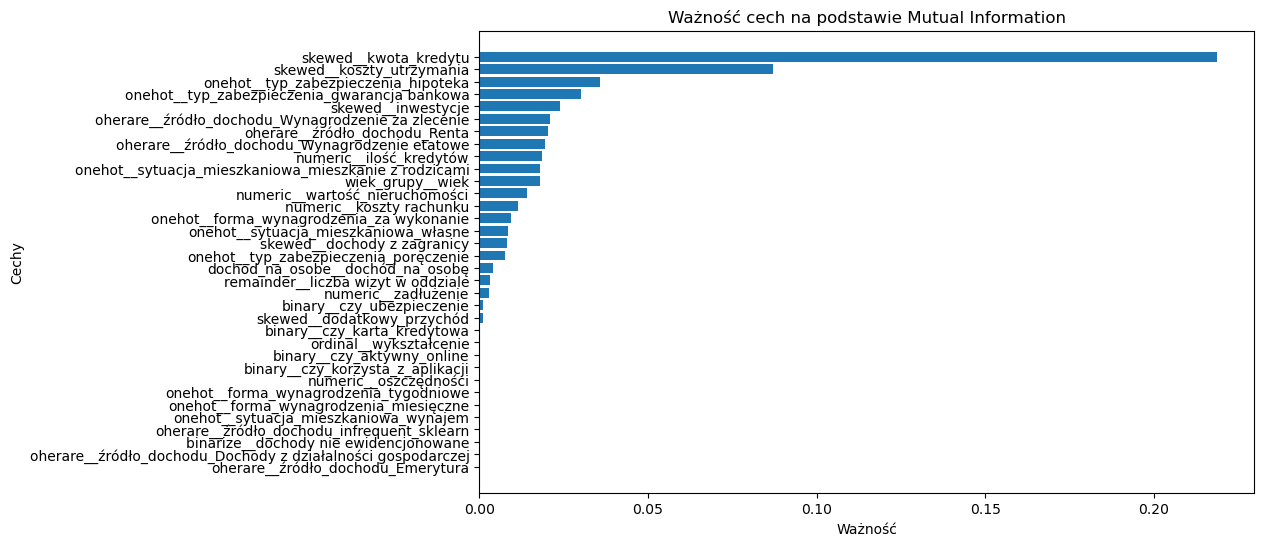

In [49]:




from sklearn.feature_selection import mutual_info_classif, SelectKBest
import pandas as pd

# Obliczenie wartości Mutual Information dla każdej cechy
mi_scores = mutual_info_classif(X_train_transformed, y_train)

# Tworzenie DataFrame z cechami i ich ważnością
mi_importance_df = pd.DataFrame({
    'Feature': X_train_transformed.columns,
    'Importance': mi_scores
}).sort_values(by='Importance', ascending=False)

# Wyświetlenie posortowanego DataFrame
display(mi_importance_df)
# Wizualizacja ważności cech za pomocą wykresu słupkowego#

import matplotlib.pyplot as plt

# Wizualizacja ważności cech za pomocą wykresu słupkowego
plt.figure(figsize=(10, 6))
plt.barh(mi_importance_df['Feature'], mi_importance_df['Importance'])
plt.xlabel('Ważność')
plt.ylabel('Cechy')
plt.title('Ważność cech na podstawie Mutual Information')
plt.gca().invert_yaxis()  # Inwersja osi Y, aby najważniejsze cechy były na górze
plt.show()


#### 5.2. Tworzenie selektora


> Utworzenie selektora na bazie SelectKBest(score_func=mutual_info_classif, k=30)) ])

In [50]:
# Pipeline do selekcji zmiennych metodą mutual information
feature_selection_pipeline_mutual = Pipeline([('selector', SelectKBest(score_func=mutual_info_classif, k=30)) ])




# # Pipeline selekcji cech na podstawie Feature Importance z RF
feature_selection_pipeline_rf = Pipeline([
    ('feature_importance', SelectFromModel(
        RandomForestClassifier(n_estimators=100, random_state=42),
        threshold=-np.inf,                                         # Umożliwia selekcję na podstawie max_features lub threshold='mean'
        max_features=25                                          # Domyślna wartość, zmieniana w siatce hiperparametrów
        ))])


feature_selection_pipeline_xgb = Pipeline([
    ('xgb', SelectFromModel(
        XGBClassifier(n_estimators=100, random_state=42),
        threshold='mean',     # Możemy ustawić próg na 'mean' lub jakąś konkretną wartość
        max_features=25       # Maksymalna liczba cech
    ))
])


from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectFromModel

feature_selection_pipeline_dt = Pipeline([
    ('dt', SelectFromModel(
        DecisionTreeClassifier(random_state=42),
        threshold='mean',     # Możemy użyć 'mean' lub ustawić odpowiedni próg
        max_features=25       # Liczba cech do wyboru
    ))
])



from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

feature_selection_pipeline_anova = Pipeline([
    ('anova', SelectKBest(f_classif, k=25))  # Wybiera 25 najlepszych cech na podstawie ANOVA F-test
])



from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

feature_selection_pipeline_chi2 = Pipeline([
    ('chi2', SelectKBest(chi2, k=25))  # Wybiera 25 najlepszych cech na podstawie testu chi-kwadrat
])



# Każdy z powyższych pipeline'ów implementuje inną metodę selekcji cech:

#     Lasso (L1 regularization) - wykorzystuje regularizację L1, która skutkuje "wygaszaniem" mniej ważnych cech.

#     Chi-squared - stosowane głównie dla zmiennych kategorycznych w celu oceny niezależności cech od klasy.

#     Mutual Information - ocenia, jakie cechy mają największą wzajemną informację z cechą docelową.

#     ANOVA F-test - test statystyczny do oceny różnic wśród grup i wyodrębniania cech.

#     XGBoost - bardziej zaawansowane podejście oparte na gradient boosting, stosowane do oceny cech na podstawie ich znaczenia.

#     Decision Tree - klasyfikator drzewa decyzyjnego, który może być użyty do wybrania najbardziej znaczących cech.

#### 5.3. Tworzenie klasyfikatora

In [51]:

model_pipeline_rf = Pipeline([('classifier', RandomForestClassifier())])      # Tworzenie potoku (pipeline) z klasyfikatorem Random Forest
model_pipeline_lr = Pipeline([('classifier', LogisticRegression())])          # Tworzenie potoku (pipeline) z klasyfikatorem Logistic Regression
model_pipeline_svc = Pipeline([('classifier', SVC())])                        # Tworzenie potoku (pipeline) z klasyfikatorem SVC
model_pipeline_knn = Pipeline([('classifier', KNeighborsClassifier())])       # Tworzenie potoku (pipeline) z klasyfikatorem KNN
model_pipeline_gb = Pipeline([ ('classifier', GradientBoostingClassifier())]) # Tworzenie potoku (pipeline) z klasyfikatorem Gradient Boosting

# Tworzenie DataFrame opisującego proces tworzenia klasyfikatora
classifier_creation_process = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression', 'SVC', 'KNN', 'Gradient Boosting'],
    'Pipeline Steps': [
        'Pipeline([("classifier", RandomForestClassifier())])',
        'Pipeline([("classifier", LogisticRegression())])',
        'Pipeline([("classifier", SVC())])',
        'Pipeline([("classifier", KNeighborsClassifier())])',
        'Pipeline([("classifier", GradientBoostingClassifier())])'
    ],
    'Description': [
        'Tworzenie potoku z klasyfikatorem Random Forest',
        'Tworzenie potoku z klasyfikatorem Logistic Regression',
        'Tworzenie potoku z klasyfikatorem SVC',
        'Tworzenie potoku z klasyfikatorem KNN',
        'Tworzenie potoku z klasyfikatorem Gradient Boosting'
    ]
})

# Wyświetlenie DataFrame
display(classifier_creation_process)

,Model,Pipeline Steps,Description
0,Random Forest,"Pipeline([(""classifier"", RandomForestClassifier())])",Tworzenie potoku z klasyfikatorem Random Forest
1,Logistic Regression,"Pipeline([(""classifier"", LogisticRegression())])",Tworzenie potoku z klasyfikatorem Logistic Regression
2,SVC,"Pipeline([(""classifier"", SVC())])",Tworzenie potoku z klasyfikatorem SVC
3,KNN,"Pipeline([(""classifier"", KNeighborsClassifier())])",Tworzenie potoku z klasyfikatorem KNN
4,Gradient Boosting,"Pipeline([(""classifier"", GradientBoostingClassifier())])",Tworzenie potoku z klasyfikatorem Gradient Boosting


#### 5.4. Ostateczny przepływ

In [55]:
model_rf = Pipeline([
    ('preprocessor', preprocessor),                               # Preprocessing
    ('feature_selection', feature_selection_pipeline_mutual),     # Selekcja zmiennych
    ('classifier', model_pipeline_rf)                                 # Model klasyfikacyjny
])


model_lr = Pipeline([
    ('preprocessor', preprocessor),                               # Preprocessing
    ('feature_selection', feature_selection_pipeline_mutual),     # Selekcja zmiennych
    ('classifier', model_pipeline_lr)                              # Model klasyfikacyjny
])


model_svc = Pipeline([
    ('preprocessor', preprocessor),                               # Preprocessing
    ('feature_selection', feature_selection_pipeline_mutual),     # Selekcja zmiennych
    ('classifier', model_pipeline_svc)                             # Model klasyfikacyjny
])


model_knn = Pipeline([
    ('preprocessor', preprocessor),                               # Preprocessing
    ('feature_selection', feature_selection_pipeline_mutual),     # Selekcja zmiennych
    ('classifier', model_pipeline_knn)                             # Model klasyfikacyjny
])


model_gb = Pipeline([
    ('preprocessor', preprocessor),                               # Preprocessing
    ('feature_selection', feature_selection_pipeline_mutual),     # Selekcja zmiennych
    ('classifier', model_pipeline_gb)                              # Model klasyfikacyjny
])


model_dt = Pipeline([
    ('preprocessor', preprocessor),                               # Preprocessing
    ('feature_selection', feature_selection_pipeline_mutual),     # Selekcja zmiennych (np. na podstawie mutual information)
    ('classifier', DecisionTreeClassifier(random_state=42))       # Model klasyfikacyjny: DecisionTreeClassifier
])



# Tworzenie DataFrame z informacjami o preprocesorze, selektorze i klasyfikatorze
pipeline_summary = pd.DataFrame({
    'Preprocesor': ['preprocessor'] * 6,
    'Selektor': [
        'feature_selection_pipeline_mutual',
        'feature_selection_pipeline_mutual',
        'feature_selection_pipeline_mutual',
        'feature_selection_pipeline_mutual',
        'feature_selection_pipeline_mutual',
        'feature_selection_pipeline_mutual'
    ],
    'Klasyfikator': [
        'model_pipeline_rf',
        'model_pipeline_lr',
        'model_pipeline_svc',
        'model_pipeline_knn',
        'model_pipeline_gb',
        'DecisionTreeClassifier'
    ]
})
pipeline_summary['Nazwa modelu'] = ['Random Forest', 'Logistic Regression', 'SVC', 'KNN', 'Gradient Boosting', 'Decision Tree']
# Wyświetlenie DataFrame
display(Markdown('**Podsumowanie pipeline\'ów:**'))
display(pipeline_summary)



**Podsumowanie pipeline'ów:**

,Preprocesor,Selektor,Klasyfikator,Nazwa modelu
0,preprocessor,feature_selection_pipeline_mutual,model_pipeline_rf,Random Forest
1,preprocessor,feature_selection_pipeline_mutual,model_pipeline_lr,Logistic Regression
2,preprocessor,feature_selection_pipeline_mutual,model_pipeline_svc,SVC
3,preprocessor,feature_selection_pipeline_mutual,model_pipeline_knn,KNN
4,preprocessor,feature_selection_pipeline_mutual,model_pipeline_gb,Gradient Boosting
5,preprocessor,feature_selection_pipeline_mutual,DecisionTreeClassifier,Decision Tree


### 5. Definiowanie walidacji krzyżowej

> Parametry:
- StratifiedKFold – technika walidacji krzyżowej, która zachowuje proporcje klas w każdym foldzie (przydatne w problemach z niezbalansowanymi danymi).
- n_splits=10 – podział zbioru na 10 równych części (foldów), gdzie 9 części jest używanych do trenowania, a 1 do testowania w każdej - shuffle=True – losowe przetasowanie danych przed podziałem, aby uniknąć zależności w kolejności obserwacji.
- andom_state=42 – ustawienie losowego ziarna w celu zapewnienia powtarzalności wyników.

To ustawienie sprawia, że model będzie testowany na różnych częściach danych, ale proporcje klas w każdym foldzie pozostaną zachowane. 

In [56]:
pd.set_option('display.max_colwidth', None)


# ==================================================================== 
# Definiowanie walidacji krzyżowej
# ====================================================================

cv_def = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) 

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold



### 6. Ewaluacja modelu wg CV dla różnych modeli klasyfikacyjnych na ustawieniach domyślnych

### celem jest:

- Ocena modeli klasyfikacyjnych: Użycie walidacji krzyżowej do uzyskania wiarygodnych metryk wydajności (dokładności i F1-score) dla różnych modeli.
- Wizualizacja wyników: Przedstawienie graficzne dokładności modelu w poszczególnych iteracjach walidacji krzyżowej, wraz z informacjami o średniej wydajności i odchyleniu standardowym.
- Porównanie modeli: Umożliwienie wizualnego porównania wydajności różnych modeli klasyfikacyjnych na tych samych danych treningowych i przy użyciu tej samej strategii walidacji krzyżowej.
- Analiza stabilności modelu: Zobaczenie, jak bardzo zmienia się dokładność modelu w różnych foldach walidacji krzyżowej, co daje wgląd w stabilność jego działania.

Model: Random Forest


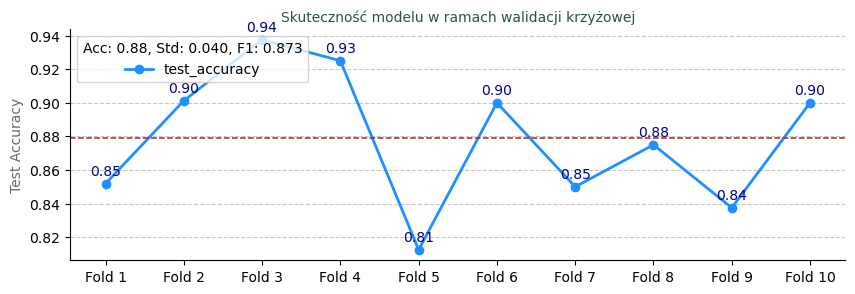

Model: K-Nearest Neighbors


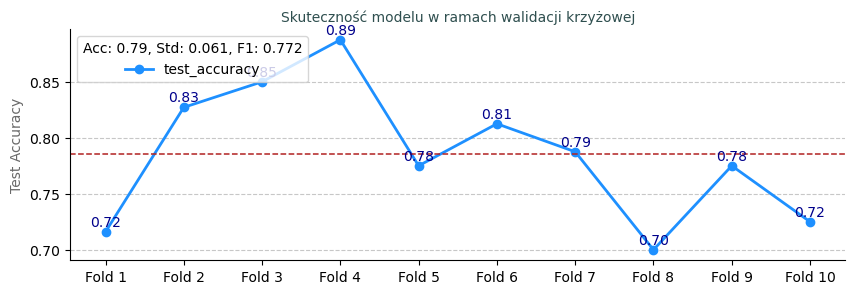

Model: Decision Tree


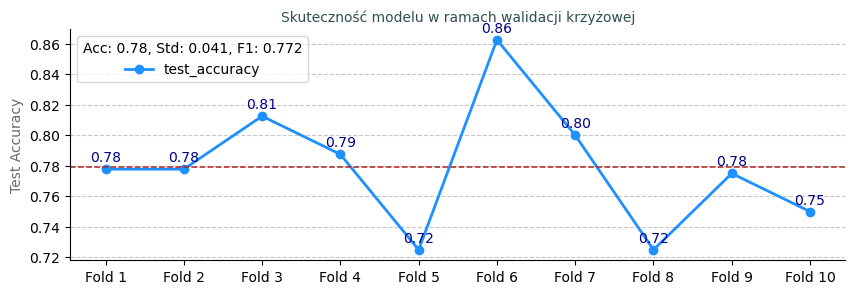

Model: Support Vector Classifier


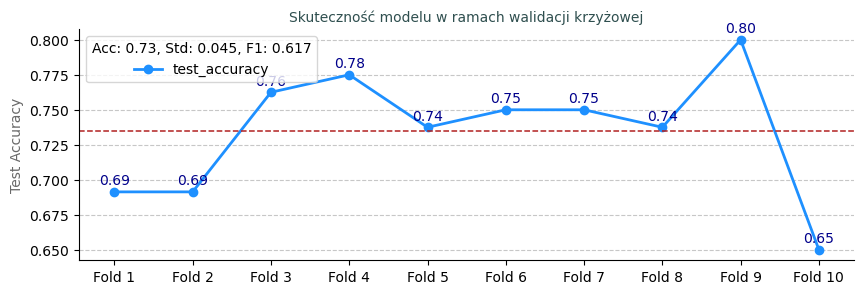

Model: Logistic Regression


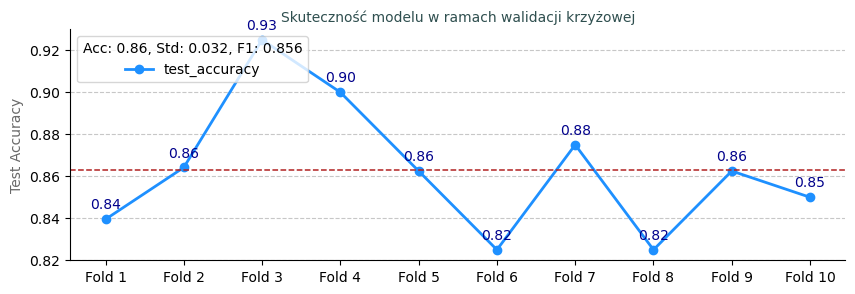

Model: Gradient Boosting


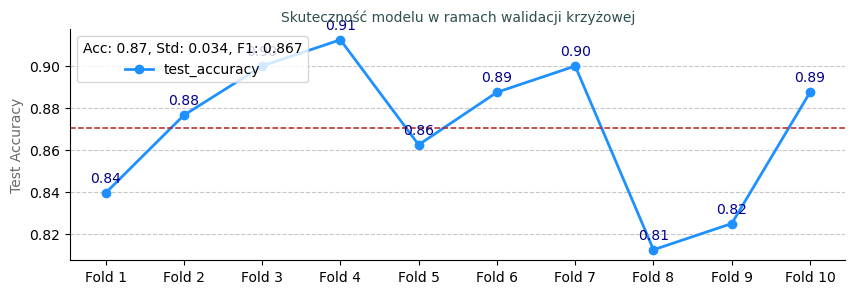

In [57]:

# # ====================================================================
# # Ewaluacja modelu wg CV dla różnych modeli klasyfikacyjnych na ustawieniach domyślnych
# # ====================================================================



import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import cross_validate

def evaluate_model_cv(model, X_train, y_train, cv):
    # Cross-validation
    cv_results = cross_validate(model, X_train, y_train, cv=cv, scoring={'accuracy': 'accuracy', 'f1': 'f1'})
    score_train = pd.DataFrame(cv_results)
    mean_accuracy = score_train["test_accuracy"].mean()
    std_accuracy = score_train["test_accuracy"].std()
    mean_f1 = score_train["test_f1"].mean()
    plt.figure(figsize=(10, 3))
    score_train["test_accuracy"].plot(kind='line', marker='o', linestyle='-', color='dodgerblue', linewidth=2, markersize=6,
                                       title='Skuteczność modelu danych testowych',
                                       xlabel='', ylabel='Test Accuracy')
    plt.axhline(y=mean_accuracy, color='firebrick', linestyle='--', linewidth=1.1)
    plt.grid(axis='y', linestyle='--', linewidth=0.8, alpha=0.7)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.legend(title=f'Acc: {mean_accuracy:.2f}, Std: {std_accuracy:.3f}, F1: {mean_f1:.3f}', loc='upper left')
    for i, v in enumerate(score_train["test_accuracy"]):
        plt.text(i, v + 0.005, f"{v:.2f}", ha='center', fontsize=10, color='darkblue')
    plt.xticks(ticks=range(len(score_train)), labels=[f'Fold {i+1}' for i in range(len(score_train))])
    plt.title('Skuteczność modelu w ramach walidacji krzyżowej', fontsize=10, color='darkslategray')
    plt.ylabel('Test Accuracy', fontsize=10, color='dimgray')
    plt.show()
    return



print("Model: Random Forest")
evaluate_model_cv(model_rf, X_train, y_train, cv_def)

print("Model: K-Nearest Neighbors")
evaluate_model_cv(model_knn, X_train, y_train, cv_def)

print("Model: Decision Tree")
evaluate_model_cv(model_dt, X_train, y_train, cv_def)

print("Model: Support Vector Classifier")
evaluate_model_cv(model_svc, X_train, y_train, cv_def)

print("Model: Logistic Regression")
evaluate_model_cv(model_lr, X_train, y_train, cv_def)

print("Model: Gradient Boosting")
evaluate_model_cv(model_gb, X_train, y_train, cv_def)






#### 6.2.Ocena wydajności modelu uczenia maszynowego w zależności od wartości hiperparametru.

In [58]:
#====================================================================================
# Ocena wydajności modelu uczenia maszynowego w zależności od wartości hiperparametru.
#====================================================================================
def plot_validation_curve(estimator, X, y, param_name, param_range, scoring='accuracy', cv=5, use_log_scale=False):
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.model_selection import validation_curve
    
    if hasattr(estimator, 'steps'):
        model_name = type(estimator.steps[-1][1]).__name__  # Pobranie nazwy modelu z pipeline
    else:
        model_name = type(estimator).__name__  # Pobranie nazwy modelu
    
    # Obliczanie wyników walidacji
    train_scores, test_scores = validation_curve(
        estimator, X, y, param_name=param_name, param_range=param_range, scoring=scoring, cv=cv)
    
    # Obliczanie średnich i odchyleń standardowych
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    # Obliczanie błędów
    train_error = 1 - train_scores
    test_error = 1 - test_scores
    train_error_mean = np.mean(train_error, axis=1)
    test_error_mean = np.mean(test_error, axis=1)
    
    # Konfiguracja wykresów
    plt.figure(figsize=(20, 4))
    
    # Subplot 1: Dokładność
    plt.subplot(1, 2, 1)
    plt.plot(param_range, train_mean, label="Dokładność treningowa", color="blue", marker="o", linewidth=2)
    plt.plot(param_range, test_mean, label="Dokładność walidacyjna", color="orange", marker="o", linewidth=2)
    plt.title(f"Krzywa Walidacyjna")
    plt.ylabel(f"{scoring.capitalize()}")
    plt.xlabel(f"{param_name}")
    plt.legend(loc="best")
    plt.grid(True)
    if use_log_scale:
        plt.xscale('log')
    else:
        plt.xticks(param_range)
    
    # Subplot 2: Błąd
    plt.subplot(1, 2, 2)
    plt.plot(param_range, train_error_mean, label="Błąd treningowy", color="red", marker="s", linewidth=2)
    plt.plot(param_range, test_error_mean, label="Błąd walidacyjny", color="green", marker="s", linewidth=2)
    plt.title(f"Krzywa Błędu ({model_name}, {param_name})")
    plt.ylabel("Error Rate")
    plt.xlabel(f"{param_name}")
    plt.legend(loc="best")
    plt.grid(True)
    if use_log_scale:
        plt.xscale('log')
    else:
        plt.xticks(param_range)
    
    plt.tight_layout()
    plt.show()



def create_validation_table(estimator, X, y, param_name, param_range, scoring='accuracy', cv=5):

    # Obliczanie wyników walidacji
    train_scores, test_scores = validation_curve(
        estimator, X, y, param_name=param_name, param_range=param_range, 
        scoring=scoring, cv=cv)
        # Obliczanie średnich
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    
    # Obliczanie błędów
    train_error = 1 - train_mean
    test_error = 1 - test_mean
    
    # Obliczanie różnicy błędów (różnica między błędem testowym a treningowym)
    error_diff = test_error - train_error
    
    # Tworzenie tabeli wyników
    results = pd.DataFrame({
        param_name: param_range,
        'Train Accuracy': train_mean,
        'Validation Accuracy': test_mean,
        'Train Error': train_error,
        'Validation Error': test_error,
        'Error Difference': error_diff
    })
    
    # Formatowanie wartości liczbowych (opcjonalnie)
    float_cols = ['Train Accuracy', 'Validation Accuracy', 'Train Error', 'Validation Error', 'Error Difference']
    results[float_cols] = results[float_cols].applymap(lambda x: f"{x:.4f}")
    
    return









Ocena modelu KNN - Validation Curve


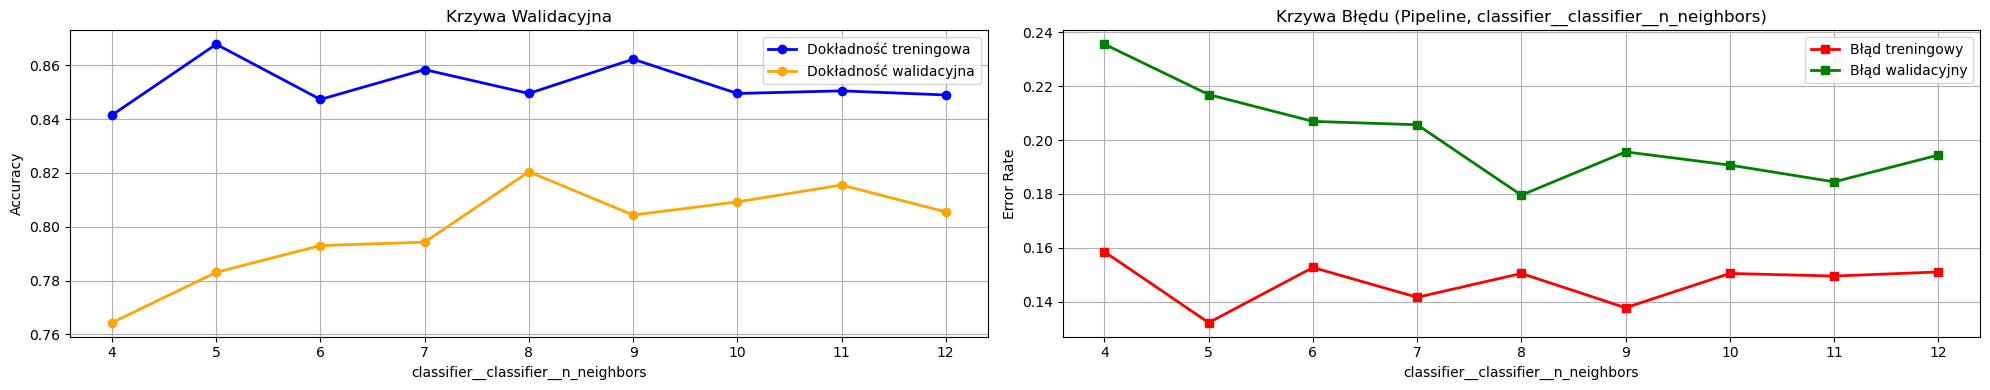

Ocena modelu Random Forest - Validation Curve


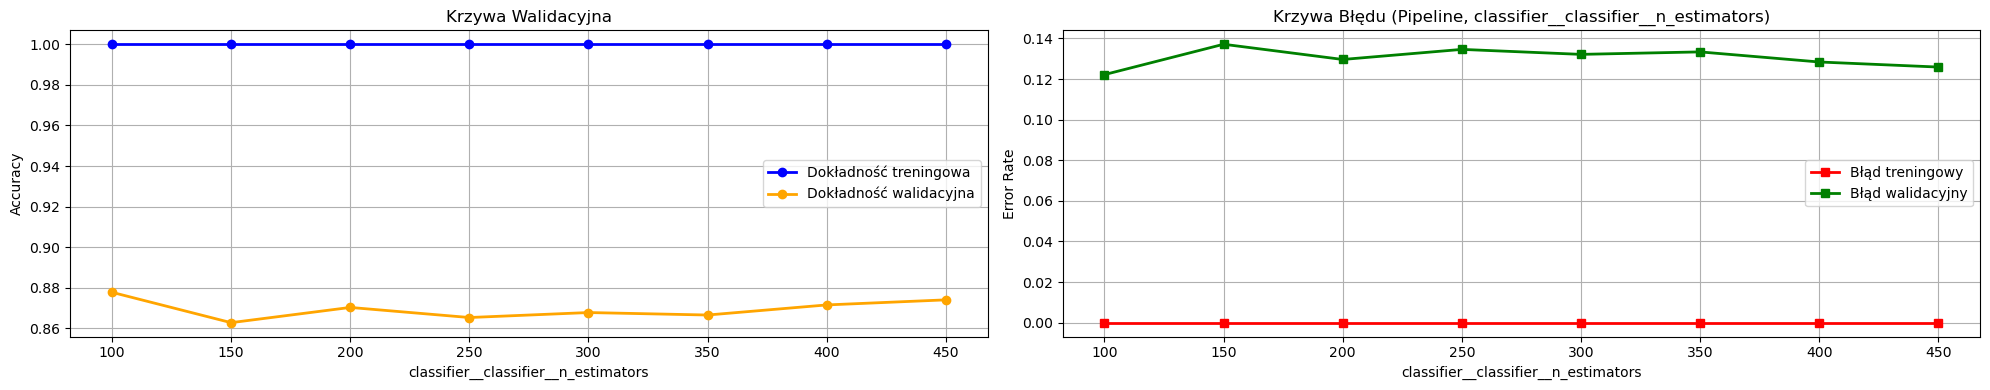

Ocena modelu Logistic Regression - Validation Curve


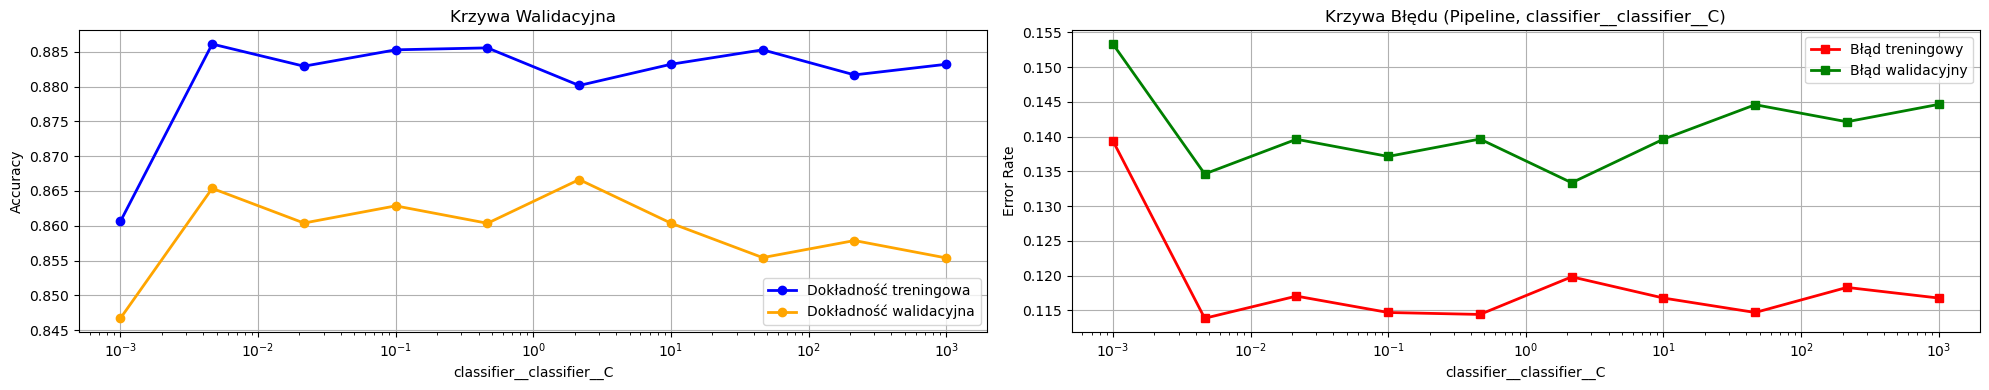

Ocena modelu SVC - Validation Curve


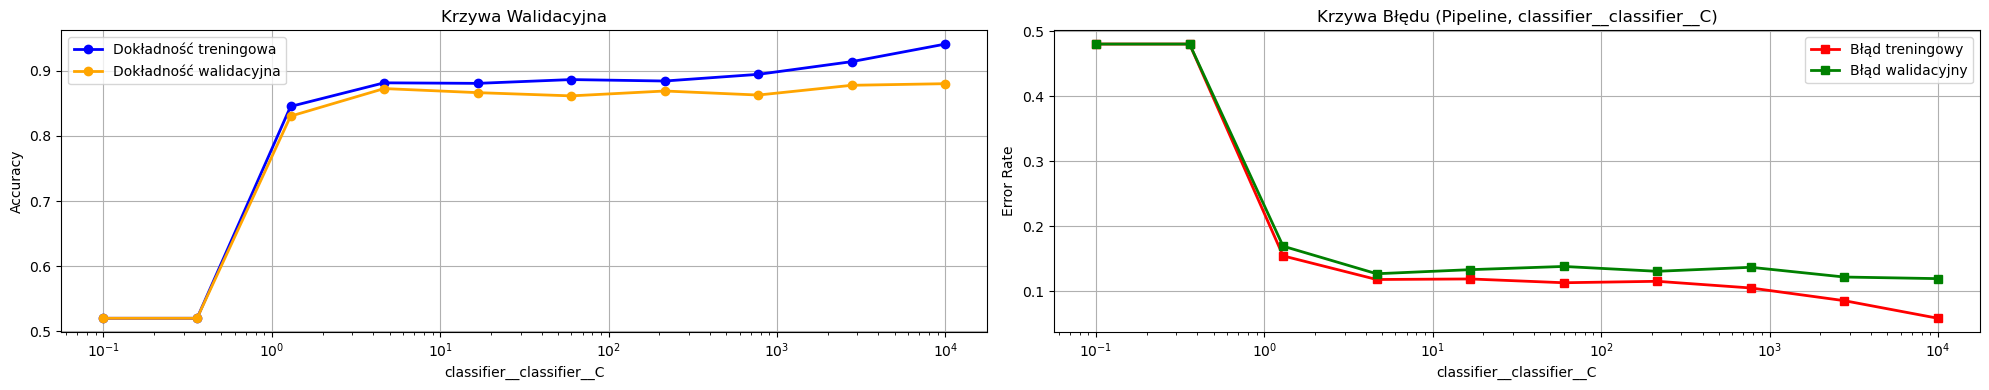

Ocena modelu Gradient Boosting - Validation Curve


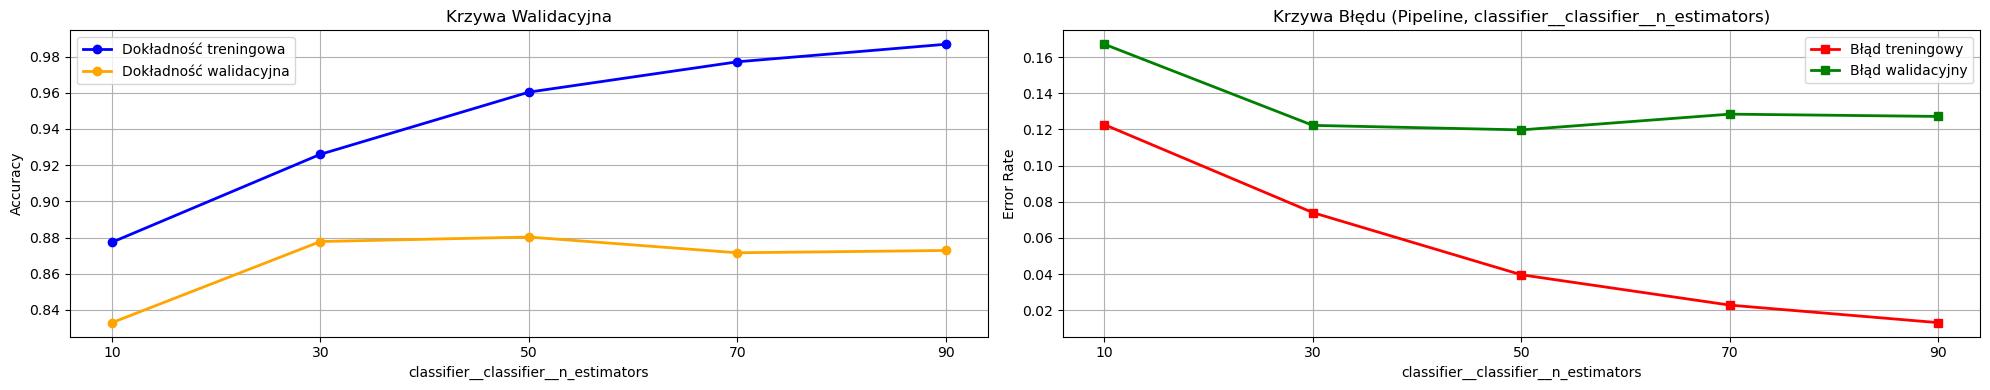

In [59]:
print("Ocena modelu KNN - Validation Curve")
plot_validation_curve(
    estimator=model_knn,
    X=X_train,
    y=y_train,
    param_name='classifier__classifier__n_neighbors',
    param_range=range(4, 13),  
    scoring='accuracy',
    cv=cv_def
)

print("Ocena modelu Random Forest - Validation Curve")
plot_validation_curve(
    estimator=model_rf,
    X=X_train,
    y=y_train,
    param_name='classifier__classifier__n_estimators',
    param_range=range(100, 500, 50),  
    scoring='accuracy',
    cv=cv_def
)

print("Ocena modelu Logistic Regression - Validation Curve")
plot_validation_curve(
    estimator=model_lr,
    X=X_train,
    y=y_train,
    param_name='classifier__classifier__C',
    param_range=np.logspace(-3, 3, 10),  
    scoring='accuracy',
    cv=cv_def,
    use_log_scale=True
)

print("Ocena modelu SVC - Validation Curve")
plot_validation_curve(
    estimator=model_svc,
    X=X_train,
    y=y_train,
    param_name='classifier__classifier__C',
    param_range=np.logspace(-1, 4, 10),  
    scoring='accuracy',
    cv=cv_def,
    use_log_scale=True
)

print("Ocena modelu Gradient Boosting - Validation Curve")
plot_validation_curve(
    estimator=model_gb,
    X=X_train,
    y=y_train,
    param_name='classifier__classifier__n_estimators',
    param_range=range(10, 100, 20),  
    scoring='accuracy',
    cv=cv_def
)


### 7.Strojenie hiperparametrów

#### 7.1. Definicja parametrów siatki

In [60]:
# ====================================================================
# Definicja siatki parametrów
# ====================================================================


param_grid = {
    # Parametry preprocessora
    'preprocessor__numeric__simpleimputer__strategy': ['mean', 'median'],
    'preprocessor__numeric__standardscaler': [StandardScaler(), MinMaxScaler(), RobustScaler()],
    'preprocessor__skewed__simpleimputer__strategy': ['mean', 'median'],
    'preprocessor__skewed__powertransformer': [
                                                PowerTransformer(method='yeo-johnson', standardize=True),
                                                PowerTransformer(method='box-cox', standardize=True)],
    'feature_selection__selector__k': [20,21,22,23,24,25,26,27,28,29,30,31,33],

    # Parametry RandomForestClassifier
     'classifier__classifier__n_estimators': [50, 100, 200],      
    'classifier__classifier__max_depth': [None, 10, 20, 30],      
    'classifier__classifier__min_samples_split': [2, 5, 10],      
    'classifier__classifier__min_samples_leaf': [1, 2, 4],        
    'classifier__classifier__max_features': ['auto', 'sqrt', 'log2'],  
    'classifier__classifier__bootstrap': [True, False],            
    'classifier__classifier__class_weight': [None, 'balanced'],    
}


# Tworzenie DataFrame z elementami parametrów siatki
param_grid_df = pd.DataFrame([
    {'Kategoria': 'Preprocessor', 'Parametr': 'preprocessor__numeric__simpleimputer__strategy', 'Wartości': ['mean', 'median']},
    {'Kategoria': 'Preprocessor', 'Parametr': 'preprocessor__numeric__standardscaler', 'Wartości': ['StandardScaler', 'MinMaxScaler', 'RobustScaler']},
    {'Kategoria': 'Preprocessor', 'Parametr': 'preprocessor__skewed__simpleimputer__strategy', 'Wartości': ['mean', 'median']},
    {'Kategoria': 'Preprocessor', 'Parametr': 'preprocessor__skewed__powertransformer', 'Wartości': ['PowerTransformer(yeo-johnson)', 'PowerTransformer(box-cox)']},
    {'Kategoria': 'Feature Selection', 'Parametr': 'feature_selection__selector__k', 'Wartości': [20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 33]},
    {'Kategoria': 'Classifier', 'Parametr': 'classifier__classifier__n_estimators', 'Wartości': [50, 100, 200]},
    {'Kategoria': 'Classifier', 'Parametr': 'classifier__classifier__max_depth', 'Wartości': [None, 10, 20, 30]},
    {'Kategoria': 'Classifier', 'Parametr': 'classifier__classifier__min_samples_split', 'Wartości': [2, 5, 10]},
    {'Kategoria': 'Classifier', 'Parametr': 'classifier__classifier__min_samples_leaf', 'Wartości': [1, 2, 4]},
    {'Kategoria': 'Classifier', 'Parametr': 'classifier__classifier__max_features', 'Wartości': ['auto', 'sqrt', 'log2']},
    {'Kategoria': 'Classifier', 'Parametr': 'classifier__classifier__bootstrap', 'Wartości': [True, False]},
    {'Kategoria': 'Classifier', 'Parametr': 'classifier__classifier__class_weight', 'Wartości': [None, 'balanced']}
])

# Wyświetlenie tabeli
display(param_grid_df)


,Kategoria,Parametr,Wartości
0,Preprocessor,preprocessor__numeric__simpleimputer__strategy,"[mean, median]"
1,Preprocessor,preprocessor__numeric__standardscaler,"[StandardScaler, MinMaxScaler, RobustScaler]"
2,Preprocessor,preprocessor__skewed__simpleimputer__strategy,"[mean, median]"
3,Preprocessor,preprocessor__skewed__powertransformer,"[PowerTransformer(yeo-johnson), PowerTransformer(box-cox)]"
4,Feature Selection,feature_selection__selector__k,"[20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 33]"
5,Classifier,classifier__classifier__n_estimators,"[50, 100, 200]"
6,Classifier,classifier__classifier__max_depth,"[None, 10, 20, 30]"
7,Classifier,classifier__classifier__min_samples_split,"[2, 5, 10]"
8,Classifier,classifier__classifier__min_samples_leaf,"[1, 2, 4]"
9,Classifier,classifier__classifier__max_features,"[auto, sqrt, log2]"


#### 7.2.Defniowanie miar oceny

In [61]:


scoring_gs = {
   "AUC": "roc_auc",
    "Accuracy": make_scorer(accuracy_score),
    "Precision": make_scorer(precision_score),
    "Recall": make_scorer(recall_score),
    "F1-score": make_scorer(f1_score),
    "AUC-PR": make_scorer(average_precision_score)
}


import pandas as pd

# Definicja tabeli z opisem metryk
metrics_info = {
    "Nazwa": ["AUC", "Accuracy", "Precision", "Recall", "F1-score", "AUC-PR"],
    "Pełna nazwa": [
        "Area Under the ROC Curve",
        "Accuracy",
        "Precision",
        "Recall (Sensitivity)",
        "F1-score",
        "Average Precision Score (AUC-PR)"
    ],
    "Opis": [
        "Pole pod krzywą ROC, mierzy zdolność modelu do rozróżniania klas.",
        "Odsetek poprawnie sklasyfikowanych obserwacji.",
        "Odsetek prawidłowo przewidzianych pozytywnych przypadków wśród wszystkich przewidzianych jako pozytywne.",
        "Odsetek prawidłowo przewidzianych pozytywnych przypadków wśród wszystkich rzeczywiście pozytywnych.",
        "Średnia harmoniczna Precision i Recall. Dobry kompromis między nimi.",
        "Pole pod krzywą Precision-Recall, szczególnie użyteczne dla niezbalansowanych klas."
    ]
}

df_metrics = pd.DataFrame(metrics_info)

display(df_metrics)




,Nazwa,Pełna nazwa,Opis
0,AUC,Area Under the ROC Curve,"Pole pod krzywą ROC, mierzy zdolność modelu do rozróżniania klas."
1,Accuracy,Accuracy,Odsetek poprawnie sklasyfikowanych obserwacji.
2,Precision,Precision,Odsetek prawidłowo przewidzianych pozytywnych przypadków wśród wszystkich przewidzianych jako pozytywne.
3,Recall,Recall (Sensitivity),Odsetek prawidłowo przewidzianych pozytywnych przypadków wśród wszystkich rzeczywiście pozytywnych.
4,F1-score,F1-score,Średnia harmoniczna Precision i Recall. Dobry kompromis między nimi.
5,AUC-PR,Average Precision Score (AUC-PR),"Pole pod krzywą Precision-Recall, szczególnie użyteczne dla niezbalansowanych klas."


#### 7.3.Przeszukiwanie hiperparametrów

In [62]:
print("Tabela parametrów RandomizedSearchCV: ")

import pandas as pd

# Dane do tabeli
random_search_info = {
    "Parametr": [
        "estimator",
        "param_distributions",
        "cv",
        "scoring",
        "n_jobs",
        "return_train_score",
        "refit",
        "n_iter",
        "random_state"
    ],
    "Wartość": [
        "model_rf",
        "param_grid",
        "cv_def",
        "scoring_gs",
        "-1",
        "True",
        "'Accuracy'",
        "100",
        "42"
    ],
    "Opis": [
        "Model poddawany optymalizacji (Random Forest w pipeline).",
        "Rozkład wartości hiperparametrów do losowania.",
        "Strategia walidacji krzyżowej.",
        "Słownik metryk oceny modelu.",
        "Liczba równoległych procesów (-1 oznacza wszystkie dostępne rdzenie CPU).",
        "Czy zapisywać wyniki na zbiorze treningowym.",
        "Metryka, według której zostanie wybrany najlepszy model.",
        "Liczba losowych kombinacji hiperparametrów do przetestowania.",
        "Seed generatora liczb losowych dla powtarzalności wyników."
    ]
}

# Tworzenie DataFrame
df_random_search = pd.DataFrame(random_search_info)

# Wyświetlenie tabeli
pd.set_option('display.max_colwidth', None)
display(df_random_search)


Tabela parametrów RandomizedSearchCV: 


,Parametr,Wartość,Opis
0,estimator,model_rf,Model poddawany optymalizacji (Random Forest w pipeline).
1,param_distributions,param_grid,Rozkład wartości hiperparametrów do losowania.
2,cv,cv_def,Strategia walidacji krzyżowej.
3,scoring,scoring_gs,Słownik metryk oceny modelu.
4,n_jobs,-1,Liczba równoległych procesów (-1 oznacza wszystkie dostępne rdzenie CPU).
5,return_train_score,True,Czy zapisywać wyniki na zbiorze treningowym.
6,refit,'Accuracy',"Metryka, według której zostanie wybrany najlepszy model."
7,n_iter,100,Liczba losowych kombinacji hiperparametrów do przetestowania.
8,random_state,42,Seed generatora liczb losowych dla powtarzalności wyników.


#### 7.4. Proces uczenia modelu na danych treningowych (X_train, y_train)

> **random_search.fit(X_train, y_train)** 

> Wywołanie metody fit obiektu RandomizedSearchCV (lub podobnego, np. GridSearchCV), gdzie:
- random_search: To instancja klasy, która implementuje losowe przeszukiwanie hiperparametrów (Randomized Search).
- X_train: To zbiór danych treningowych (cechy), na którym model będzie trenowany i walidowany w procesie poszukiwania najlepszych hiperparametrów.
- y_train: To etykiety odpowiadające danym treningowym, używane do oceny wydajności modelu dla różnych kombinacji hiperparametrów.


In [63]:
import pandas as pd

# Przygotowanie danych do tabeli
data = {
    "Etap": [
        "Losowanie kombinacji hiperparametrów",
        "Walidacja krzyżowa",
        "Ewaluacja metryk",
        "Zapis wyników",
        "Wybór najlepszego modelu",
        "Dostęp do najlepszych wyników"
    ],
    "Opis": [
        "Losuje 100 różnych zestawów hiperparametrów z podanego rozkładu param_grid.",
        "Dla każdej kombinacji wykonuje walidację krzyżową zgodnie z obiektem cv_def.",
        "Dla każdego podziału danych obliczane są metryki ze słownika scoring_gs: Accuracy, AUC, Precision, Recall, F1-score, AUC-PR.",
        "Wyniki walidacji zapisywane są w atrybucie .cv_results_. Dzięki return_train_score=True zapisywane są również wyniki na zbiorze treningowym.",
        "Na podstawie metryki Accuracy (parametr refit='Accuracy') wybierany jest najlepszy zestaw hiperparametrów. Model z tymi parametrami jest trenowany na pełnym zbiorze treningowym.",
        "Po zakończeniu procesu dostępne są: best_params_ (najlepsze hiperparametry), best_score_ (najlepszy wynik Accuracy), best_estimator_ (najlepszy model)."
    ]
}

# Utworzenie DataFrame
df_explanation = pd.DataFrame(data)

# Wyświetlenie tabeli
pd.set_option('display.max_colwidth', None)
display(df_explanation)


,Etap,Opis
0,Losowanie kombinacji hiperparametrów,Losuje 100 różnych zestawów hiperparametrów z podanego rozkładu param_grid.
1,Walidacja krzyżowa,Dla każdej kombinacji wykonuje walidację krzyżową zgodnie z obiektem cv_def.
2,Ewaluacja metryk,"Dla każdego podziału danych obliczane są metryki ze słownika scoring_gs: Accuracy, AUC, Precision, Recall, F1-score, AUC-PR."
3,Zapis wyników,Wyniki walidacji zapisywane są w atrybucie .cv_results_. Dzięki return_train_score=True zapisywane są również wyniki na zbiorze treningowym.
4,Wybór najlepszego modelu,Na podstawie metryki Accuracy (parametr refit='Accuracy') wybierany jest najlepszy zestaw hiperparametrów. Model z tymi parametrami jest trenowany na pełnym zbiorze treningowym.
5,Dostęp do najlepszych wyników,"Po zakończeniu procesu dostępne są: best_params_ (najlepsze hiperparametry), best_score_ (najlepszy wynik Accuracy), best_estimator_ (najlepszy model)."


In [65]:


# # ====================================================================
# # Przeszukiwanie hiperparametrów
# # ====================================================================


random_search = RandomizedSearchCV(
    model_rf,
    param_distributions=param_grid, 
    cv=cv_def,
    scoring=scoring_gs,
    n_jobs=-1,
    return_train_score=True,
    refit="Accuracy",
    n_iter=100,  
    random_state=42  
)

random_search.fit(X_train, y_train)






/tmp/ipykernel_4543/98414040.py:41: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


/tmp/ipykernel_4543/98414040.py:41: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[c

RandomizedSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('binary',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('ordinalencoder',
                                                                                                OrdinalEncoder()),
                                                                                               ('binarizer',
                                                                                                Binarizer(threshold=0.5))]),
                                                                               ['czy_karta...
                   scoring={'AUC': 'roc_auc',
                            'AUC-PR': make_scorer(average_precision_score, response_method='predict'),
                            'Accuracy': make_scorer(accuracy_score, response_method='predict'),
                            'F1-score': make_scorer(f1_score, response_method='predict'),
                            'Precision': make_scorer(precision_score, response_method='predict'),
                            'Recall': make_scorer(recall_score, response_method='predict')})

### 8. Wybranie optymalnych hiperparametrów dla modelu

In [80]:

# Wyświetlenie najlepszego modelu i jego parametrów
best_model = random_search.best_estimator_
best_params = random_search.best_params_
best_score = random_search.best_score_

cv_results = random_search.cv_results_
results_df = pd.DataFrame(cv_results)

# Wybierz tylko kolumny z średnimi testowymi miarami
mean_test_measures = [col for col in results_df.columns if col.startswith('mean_test_')]

# Dodaj kolumnę params, aby mieć informacje o parametrach
selected_cols = ['params'] + mean_test_measures

# Wyświetl DataFrame z wybranymi kolumnami, posortowany według rankingu (jeśli istnieje)
print("\nŚrednie testowe miary:")
try:
    display(results_df[selected_cols].sort_values(by= [col for col in results_df.columns if col.startswith('mean_test__')][0]))
except IndexError:
    display(results_df[selected_cols].head(1).T)


Średnie testowe miary:


,0
params,"{'preprocessor__skewed__simpleimputer__strategy': 'mean', 'preprocessor__skewed__powertransformer': PowerTransformer(method='box-cox'), 'preprocessor__numeric__standardscaler': StandardScaler(), 'preprocessor__numeric__simpleimputer__strategy': 'median', 'feature_selection__selector__k': 31, 'classifier__classifier__n_estimators': 50, 'classifier__classifier__min_samples_split': 5, 'classifier__classifier__min_samples_leaf': 2, 'classifier__classifier__max_features': 'log2', 'classifier__classifier__max_depth': None, 'classifier__classifier__class_weight': 'balanced', 'classifier__classifier__bootstrap': True}"
mean_test_AUC,0.934082
mean_test_Accuracy,0.861636
mean_test_Precision,0.862312
mean_test_Recall,0.851889
mean_test_F1-score,0.855769
mean_test_AUC-PR,0.806677


#### 8.1. Wybranie modelu i jego hiperparametrów

In [97]:
print("Najlepszy klasyfikator:")
print(RandomForestClassifier())

Najlepszy klasyfikator:
RandomForestClassifier()


In [91]:
print("Najlepsze parametry")
best_params

Najlepsze parametry


{'preprocessor__skewed__simpleimputer__strategy': 'median',
 'preprocessor__skewed__powertransformer': PowerTransformer(),
 'preprocessor__numeric__standardscaler': StandardScaler(),
 'preprocessor__numeric__simpleimputer__strategy': 'median',
 'feature_selection__selector__k': 29,
 'classifier__classifier__n_estimators': 100,
 'classifier__classifier__min_samples_split': 2,
 'classifier__classifier__min_samples_leaf': 2,
 'classifier__classifier__max_features': 'log2',
 'classifier__classifier__max_depth': 20,
 'classifier__classifier__class_weight': 'balanced',
 'classifier__classifier__bootstrap': True}

In [98]:
print("Najlepsza miara skuteczności na zbiorze treningowym:")
round(best_score,4)

Najlepsza miara skuteczności na zbiorze treningowym:


0.8815

### 9. Predykcja  i ocena modelu na danych testowych

In [114]:

# # ====================================================================
# # Predykcja  i ocena modelu na danych testowych
# # ====================================================================



# Predykcje modelu
y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1]  # prawdopodobieństwa dla klasy pozytywnej

# Obliczenie macierzy konfuzji
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

# Obliczenie dodatkowych metryk
accuracy_test = accuracy_score(y_test, y_pred_test)
error_ratio = (fp + fn) / (tp + fp + fn + tn)  # stosunek błędów do wszystkich predykcji
precision_pos = precision_score(y_test, y_pred_test, pos_label=1)
precision_neg = precision_score(y_test, y_pred_test, pos_label=0)
recall_pos = recall_score(y_test, y_pred_test, pos_label=1)
recall_neg = recall_score(y_test, y_pred_test, pos_label=0)
f1_test = f1_score(y_test, y_pred_test)
roc_auc_test = roc_auc_score(y_test, y_prob_test)
cohen_kappa = cohen_kappa_score(y_test, y_pred_test)
matthews_corrcoef_score = matthews_corrcoef(y_test, y_pred_test)

# # Wyświetlenie wyników
# print("Wyniki na danych testowych:")
# print(f"TP (True Positives): {tp}")
# print(f"FP (False Positives): {fp}")
# print(f"FN (False Negatives): {fn}")
# print(f"TN (True Negatives): {tn}")
# print(f"Accuracy: {accuracy_test:.4f}")
# print(f"Error Ratio: {error_ratio:.4f}")
# print(f"Precision (Positive Class): {precision_pos:.4f}")
# print(f"Precision (Negative Class): {precision_neg:.4f}")
# print(f"Recall (Positive Class): {recall_pos:.4f}")
# print(f"Recall (Negative Class): {recall_neg:.4f}")
# print(f"F1-score: {f1_test:.4f}")
# print(f"ROC AUC: {roc_auc_test:.4f}")
# print(f"Cohen's Kappa: {cohen_kappa:.4f}")
# print(f"Matthews Correlation Coefficient: {matthews_corrcoef_score:.4f}")

# Tworzenie słownika z wynikami


# ... (Twój wcześniejszy kod, który oblicza tp, fp, fn, tn, accuracy_test, error_ratio, etc.) ...

results = {
    "Metryka": ["TP", "FP", "FN", "TN", "Accuracy", "Error Ratio", "Precision (Positive)",
               "Precision (Negative)", "Recall (Positive)", "Recall (Negative)", "F1-score",
               "ROC AUC", "Cohen's Kappa", "Matthews Correlation Coefficient"],
    "Wartość": [tp, fp, fn, tn, accuracy_test, error_ratio, precision_pos,
              precision_neg, recall_pos, recall_neg, f1_test,
              roc_auc_test, cohen_kappa, matthews_corrcoef_score],
    "Definicja": [
        "True Positives: Liczba poprawnie przewidzianych pozytywnych przypadków.",
        "False Positives: Liczba błędnie przewidzianych pozytywnych przypadków (błędy typu I).",
        "False Negatives: Liczba błędnie przewidzianych negatywnych przypadków (błędy typu II).",
        "True Negatives: Liczba poprawnie przewidzianych negatywnych przypadków.",
        "Accuracy: Odsetek poprawnie przewidzianych przypadków (wszystkie poprawne / wszystkie przypadki).",
        "Error Ratio: Odsetek błędnie przewidzianych przypadków (wszystkie błędne / wszystkie przypadki).",
        "Precision (Positive): Dokładność przewidywania pozytywnych przypadków (TP / (TP + FP)).",
        "Precision (Negative): Dokładność przewidywania negatywnych przypadków (TN / (TN + FN)).",
        "Recall (Positive): Pokrycie pozytywnych przypadków (TP / (TP + FN)).",
        "Recall (Negative): Pokrycie negatywnych przypadków (TN / (TN + FP)).",
        "F1-score: Średnia harmoniczna precyzji i pokrycia (2 * (precision * recall) / (precision + recall)).",
        "ROC AUC: Obszar pod krzywą ROC, miara zdolności modelu do rozróżniania klas.",
        "Cohen's Kappa: Miara zgodności między przewidywaniami a rzeczywistością, uwzględniająca losowość.",
        "Matthews Correlation Coefficient: Miara korelacji między przewidywaniami a rzeczywistością dla klas niezbalansowanych."
    ]
}

results_df = pd.DataFrame(results)

# Tworzenie DataFrame z wyników
results_df = pd.DataFrame(results)

# Wyświetlanie DataFrame
print("Wyniki na danych testowych:")
display(results_df)

print()



report = classification_report(y_test, y_pred_test, output_dict=True)
report_df = pd.DataFrame(report).transpose()

print("Raport klasyfikacji:")
display(report_df)
#4min


Wyniki na danych testowych:


,Metryka,Wartość,Definicja
0,TP,83.000000,True Positives: Liczba poprawnie przewidzianych pozytywnych przypadków.
1,FP,16.000000,False Positives: Liczba błędnie przewidzianych pozytywnych przypadków (błędy typu I).
2,FN,14.000000,False Negatives: Liczba błędnie przewidzianych negatywnych przypadków (błędy typu II).
3,TN,88.000000,True Negatives: Liczba poprawnie przewidzianych negatywnych przypadków.
4,Accuracy,0.850746,Accuracy: Odsetek poprawnie przewidzianych przypadków (wszystkie poprawne / wszystkie przypadki).
5,Error Ratio,0.149254,Error Ratio: Odsetek błędnie przewidzianych przypadków (wszystkie błędne / wszystkie przypadki).
6,Precision (Positive),0.838384,Precision (Positive): Dokładność przewidywania pozytywnych przypadków (TP / (TP + FP)).
7,Precision (Negative),0.862745,Precision (Negative): Dokładność przewidywania negatywnych przypadków (TN / (TN + FN)).
8,Recall (Positive),0.855670,Recall (Positive): Pokrycie pozytywnych przypadków (TP / (TP + FN)).
9,Recall (Negative),0.846154,Recall (Negative): Pokrycie negatywnych przypadków (TN / (TN + FP)).



Raport klasyfikacji:


,precision,recall,f1-score,support
0,0.862745,0.846154,0.854369,104.000000
1,0.838384,0.855670,0.846939,97.000000
accuracy,0.850746,0.850746,0.850746,0.850746
macro avg,0.850564,0.850912,0.850654,201.000000
weighted avg,0.850989,0.850746,0.850783,201.000000


## Interpretacja Wyników Modelu

### Metryki i Ich Interpretacja

* **TP (True Positives): 83**
    * Model poprawnie przewidział 83 przypadki pozytywne.
* **FP (False Positives): 16**
    * Model błędnie zaklasyfikował 16 przypadków jako pozytywne (błędy typu I).
* **FN (False Negatives): 14**
    * Model błędnie zaklasyfikował 14 przypadków jako negatywne (błędy typu II).
* **TN (True Negatives): 88**
    * Model poprawnie przewidział 88 przypadków negatywnych.
* **Accuracy (Dokładność): 0.850746**
    * Model poprawnie przewidział 85.07% wszystkich przypadków.
* **Error Ratio (Współczynnik Błędu): 0.149254**
    * Model błędnie przewidział 14.93% wszystkich przypadków.
* **Precision (Positive) (Precyzja dla Klasy Pozytywnej): 0.838384**
    * Gdy model przewidział klasę pozytywną, miał rację w 83.84% przypadków.
* **Precision (Negative) (Precyzja dla Klasy Negatywnej): 0.862745**
    * Gdy model przewidział klasę negatywną, miał rację w 86.27% przypadków.
* **Recall (Positive) (Pokrycie dla Klasy Pozytywnej): 0.855670**
    * Model poprawnie zidentyfikował 85.57% wszystkich rzeczywistych przypadków pozytywnych.
* **Recall (Negative) (Pokrycie dla Klasy Negatywnej): 0.846154**
    * Model poprawnie zidentyfikował 84.62% wszystkich rzeczywistych przypadków negatywnych.
* **F1-score: 0.846939**
    * Średnia harmoniczna precyzji i pokrycia, wskazująca na zrównoważoną wydajność.
* **ROC AUC: 0.934774**
    * Obszar pod krzywą ROC, wskazujący na dobrą zdolność modelu do rozróżniania klas.
* **Cohen's Kappa: 0.701337**
    * Miara zgodności między przewidywaniami a rzeczywistością, uwzględniająca losowość.
* **Matthews Correlation Coefficient (MCC): 0.701476**
    * Miara korelacji między przewidywaniami a rzeczywistością, szczególnie przydatna dla niezbalansowanych klas.


* **Precision (Positive) (Precyzja dla Klasy Pozytywnej): 0.838384**
    * Gdy model przewidział klasę pozytywną, miał rację w 83.84% przypadków.
* **Precision (Negative) (Precyzja dla Klasy Negatywnej): 0.862745**
    * Gdy model przewidział klasę negatywną, miał rację w 86.27% przypadków.
* **Recall (Positive) (Pokrycie dla Klasy Pozytywnej): 0.855670**
    * Model poprawnie zidentyfikował 85.57% wszystkich rzeczywistych przypadków pozytywnych.
* **Recall (Negative) (Pokrycie dla Klasy Negatywnej): 0.846154**
    * Model poprawnie zidentyfikował 84.62% wszystkich rzeczywistych przypadków negatywnych.


### Podsumowanie

* Model wykazuje ogólnie dobrą wydajność, z dokładnością wynoszącą około 85%.
* Precyzja i pokrycie są dość zrównoważone dla obu klas, co jest pozytywne.
* Wysoka wartość ROC AUC (0.93) wskazuje na dobrą zdolność modelu do rozróżniania klas.
* Wartości Cohen's Kappa i MCC wskazują na umiarkowaną do dobrej zgodność przewidywań z rzeczywistością.
* Ogólnie rzecz biorąc, model jest dobrze dopasowany do danych.

> Raport klasyfikacji dostarcza miary (precision, recall, f1-score) dla każdej z klas oddzielnie. Oznacza to, że:
- Miary dla klasy 0 pokazują, jak dobrze model radzi sobie z przewidywaniem przypadków należących do klasy 0.
- Miary dla klasy 1 pokazują, jak dobrze model radzi sobie z przewidywaniem przypadków należących do klasy 1.

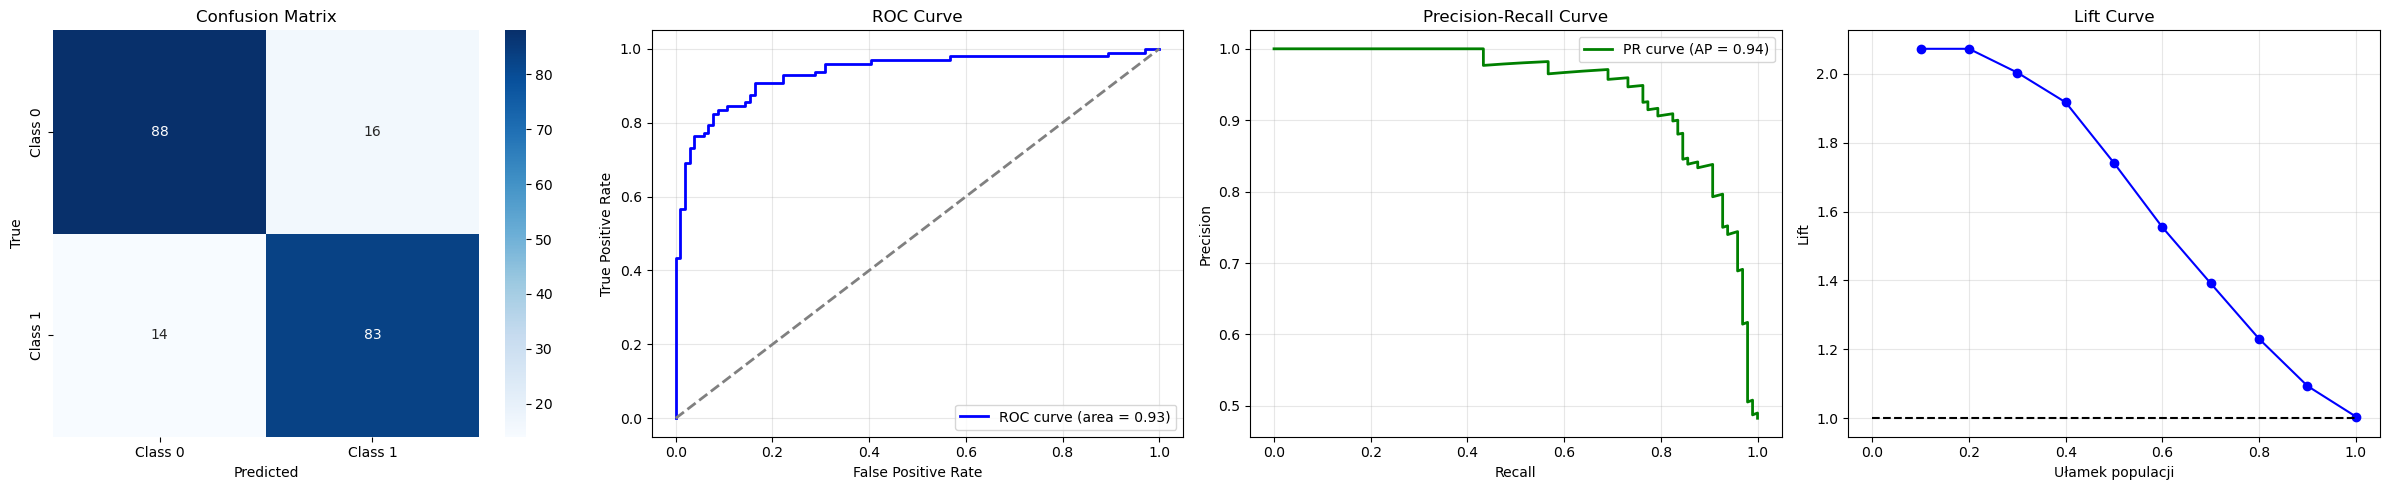

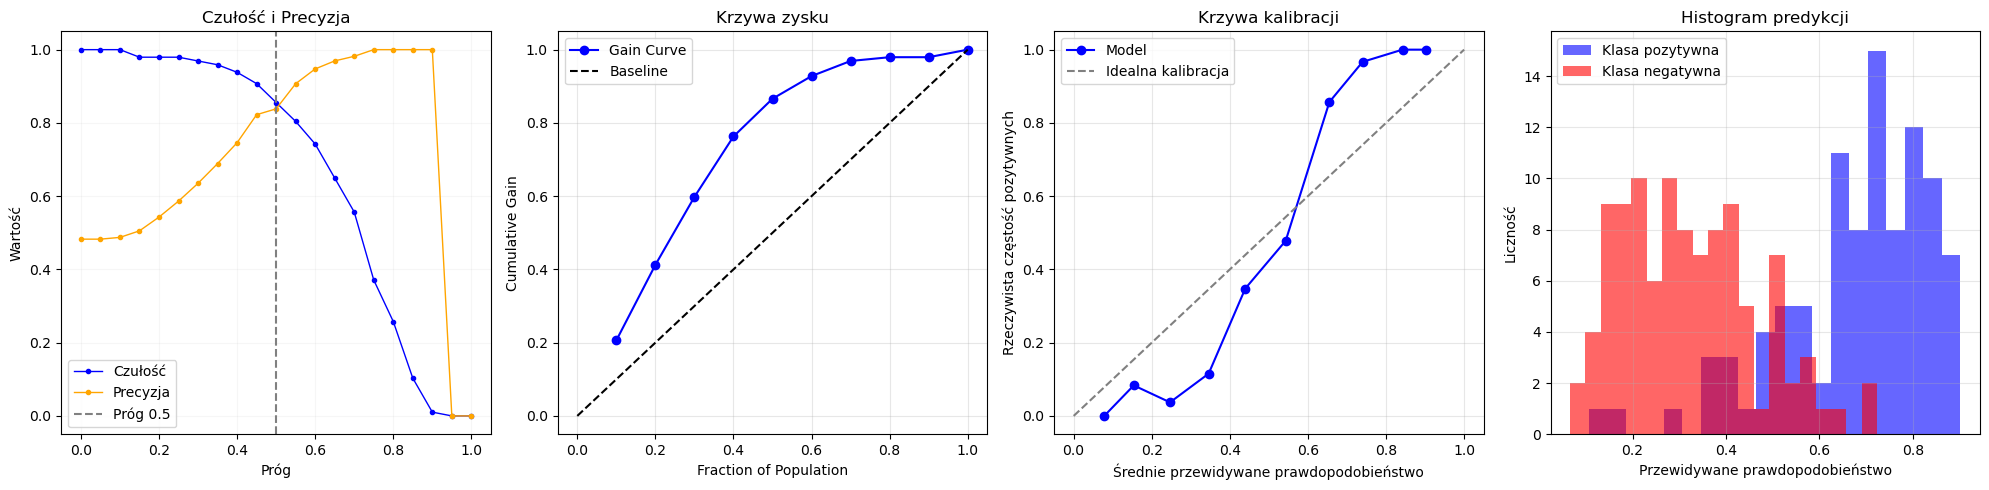

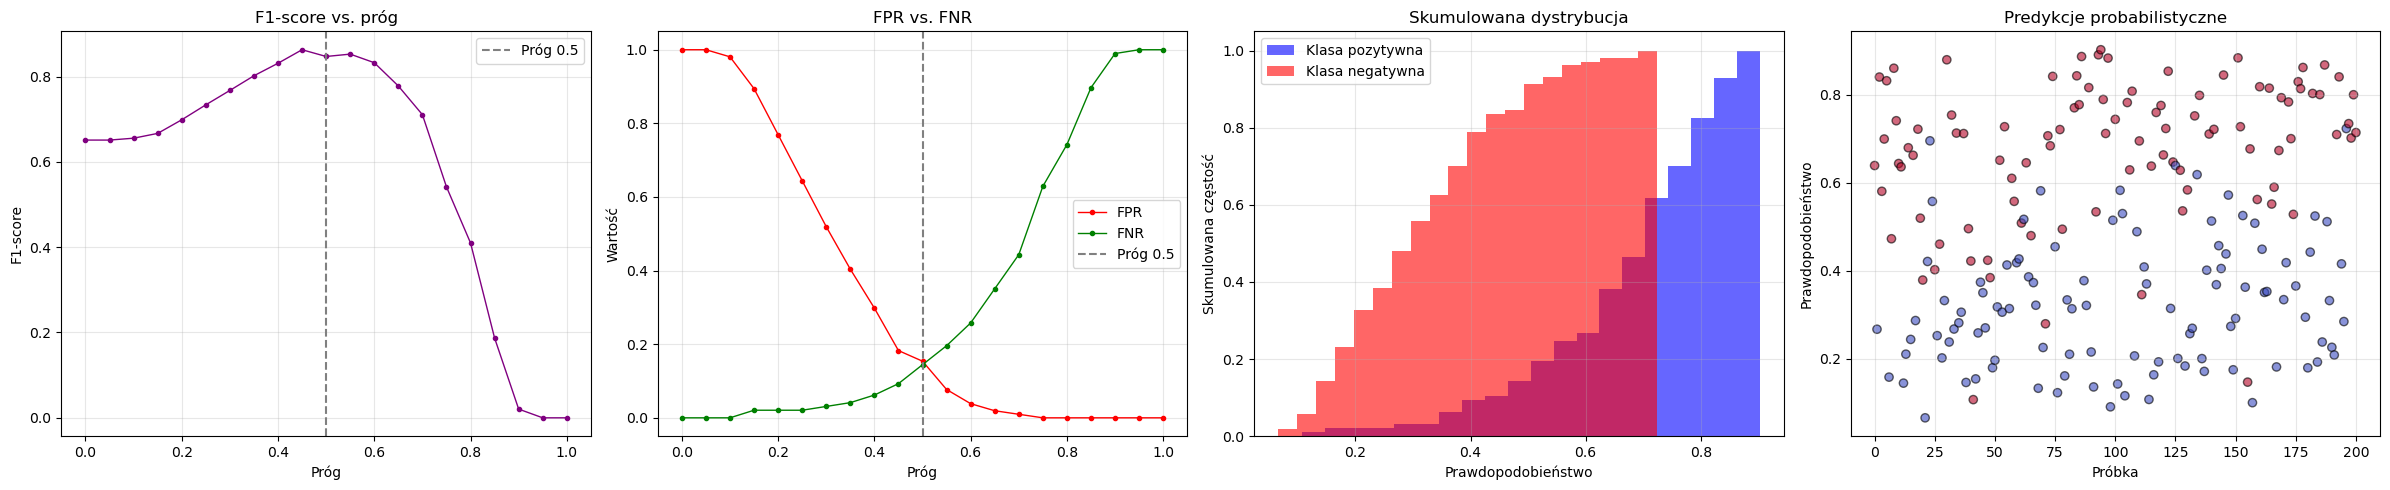

In [115]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (roc_curve, auc, precision_recall_curve, average_precision_score, 
                             confusion_matrix)


def plot_all_metrics(y_test, y_pred, y_prob, classes=['Class 0', 'Class 1'], bins=10):
    fig, axes = plt.subplots(1, 4, figsize=(24, 5))

    # Macierz konfuzji
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes, ax=axes[0])
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    axes[0].set_title('Confusion Matrix')

    # Krzywa ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    axes[1].plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve')
    axes[1].legend(loc="lower right")
    axes[1].grid(True, alpha=0.3)

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    average_precision = average_precision_score(y_test, y_prob)
    axes[2].plot(recall, precision, color='green', lw=2, label=f'PR curve (AP = {average_precision:.2f})')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].set_title('Precision-Recall Curve')
    axes[2].legend(loc="best")
    axes[2].grid(True, alpha=0.3)

    # Krzywa Lift
    indices = np.argsort(y_prob)[::-1]
    sorted_y_true = np.array(y_test)[indices]
    population_size = len(y_test)
    bin_size = population_size // bins
    positive_rate = np.mean(y_test)
    lifts, x_points = [], []
    for i in range(bins):
        bin_end = (i + 1) * bin_size if (i + 1) * bin_size <= population_size else population_size
        bin_positive_rate = np.mean(sorted_y_true[:bin_end])
        lifts.append(bin_positive_rate / positive_rate)
        x_points.append((i + 1) / bins)
    axes[3].plot(x_points, lifts, 'b-', marker='o')
    axes[3].plot([0, 1], [1, 1], 'k--')
    axes[3].set_xlabel('Ułamek populacji')
    axes[3].set_ylabel('Lift')
    axes[3].set_title('Lift Curve')
    axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_all_metrics(y_test, y_pred_test, y_prob_test)



import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# Listy na wyniki
sensitivities = []
precisions = []

# Definicja progów decyzyjnych
thresholds = np.arange(0, 1.01, 0.05)
for threshold in thresholds:
    y_pred_thresh = (y_prob_test >= threshold).astype(int)
    tp = ((y_test == 1) & (y_pred_thresh == 1)).sum()
    fp = ((y_test == 0) & (y_pred_thresh == 1)).sum()
    fn = ((y_test == 1) & (y_pred_thresh == 0)).sum()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    sensitivities.append(sensitivity)
    precisions.append(precision)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Wykres czułości i precyzji
axes[0].plot(thresholds, sensitivities, label='Czułość', marker='o', color='blue', linewidth=1, markersize=3)
axes[0].plot(thresholds, precisions, label='Precyzja', marker='o', color='orange', linewidth=1, markersize=3)
axes[0].axvline(x=0.5, color='gray', linestyle='--', label='Próg 0.5')
axes[0].set_title('Czułość i Precyzja')
axes[0].set_xlabel('Próg')
axes[0].set_ylabel('Wartość')
axes[0].legend()
axes[0].grid(alpha=0.1)

# Krzywa zysku
sorted_indices = np.argsort(y_prob_test)[::-1]
sorted_y_true = np.array(y_test)[sorted_indices]
population_size = len(y_test)
bin_size = population_size // 10
cumulative_gains, x_points = [], []
total_positives = np.sum(y_test)
for i in range(10):
    bin_end = (i + 1) * bin_size if (i + 1) * bin_size <= population_size else population_size
    cumulative_positives = np.sum(sorted_y_true[:bin_end])
    cumulative_gains.append(cumulative_positives / total_positives)
    x_points.append((i + 1) / 10)
axes[1].plot(x_points, cumulative_gains, 'b-', marker='o', label='Gain Curve')
axes[1].plot([0, 1], [0, 1], 'k--', label='Baseline')
axes[1].set_title('Krzywa zysku')
axes[1].set_xlabel('Fraction of Population')
axes[1].set_ylabel('Cumulative Gain')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Krzywa kalibracji
prob_true, prob_pred = calibration_curve(y_test, y_prob_test, n_bins=10)
axes[2].plot(prob_pred, prob_true, marker='o', color='blue', label='Model')
axes[2].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Idealna kalibracja')
axes[2].set_title('Krzywa kalibracji')
axes[2].set_xlabel('Średnie przewidywane prawdopodobieństwo')
axes[2].set_ylabel('Rzeczywista częstość pozytywnych')
axes[2].legend()
axes[2].grid(alpha=0.3)

# Histogram prawdopodobieństw
axes[3].hist(y_prob_test[y_test == 1], bins=20, alpha=0.6, color='blue', label='Klasa pozytywna')
axes[3].hist(y_prob_test[y_test == 0], bins=20, alpha=0.6, color='red', label='Klasa negatywna')
axes[3].set_title('Histogram predykcji')
axes[3].set_xlabel('Przewidywane prawdopodobieństwo')
axes[3].set_ylabel('Liczność')
axes[3].legend()
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()


import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# Przygotowanie danych (załóżmy, że masz już y_test i y_prob_test)
# thresholds
thresholds = np.arange(0, 1.01, 0.05)

# F1-score w zależności od progu
f1_scores = []
for threshold in thresholds:
    y_pred_thresh = (y_prob_test >= threshold).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_thresh))

# FPR i FNR
fpr_values = []
fnr_values = []

for threshold in thresholds:
    y_pred_thresh = (y_prob_test >= threshold).astype(int)
    fp = ((y_test == 0) & (y_pred_thresh == 1)).sum()
    fn = ((y_test == 1) & (y_pred_thresh == 0)).sum()
    tn = ((y_test == 0) & (y_pred_thresh == 0)).sum()
    tp = ((y_test == 1) & (y_pred_thresh == 1)).sum()
    
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    
    fpr_values.append(fpr)
    fnr_values.append(fnr)

# Tworzenie subplots
fig, axs = plt.subplots(1, 4, figsize=(24, 5))

# Wykres F1-score
axs[0].plot(thresholds, f1_scores, marker='o', color='purple', linewidth=1, markersize=3)
axs[0].axvline(x=0.5, color='gray', linestyle='--', label='Próg 0.5')
axs[0].set_xlabel('Próg')
axs[0].set_ylabel('F1-score')
axs[0].set_title('F1-score vs. próg')
axs[0].legend()
axs[0].grid(alpha=0.3)

# Wykres FPR i FNR
axs[1].plot(thresholds, fpr_values, label='FPR', marker='o', color='red', linewidth=1, markersize=3)
axs[1].plot(thresholds, fnr_values, label='FNR', marker='o', color='green', linewidth=1, markersize=3)
axs[1].axvline(x=0.5, color='gray', linestyle='--', label='Próg 0.5')
axs[1].set_xlabel('Próg')
axs[1].set_ylabel('Wartość')
axs[1].set_title('FPR vs. FNR')
axs[1].legend()
axs[1].grid(alpha=0.3)

# Skumulowany wykres dystrybucji
axs[2].hist(y_prob_test[y_test == 1], bins=20, alpha=0.6, color='blue', label='Klasa pozytywna', cumulative=True, density=True)
axs[2].hist(y_prob_test[y_test == 0], bins=20, alpha=0.6, color='red', label='Klasa negatywna', cumulative=True, density=True)
axs[2].set_xlabel('Prawdopodobieństwo')
axs[2].set_ylabel('Skumulowana częstość')
axs[2].set_title('Skumulowana dystrybucja')
axs[2].legend()
axs[2].grid(alpha=0.3)

# Wykres punktowy prawdopodobieństw
scatter = axs[3].scatter(np.arange(len(y_test)), y_prob_test, c=y_test, cmap='coolwarm', edgecolors='k', alpha=0.6)
axs[3].set_xlabel('Próbka')
axs[3].set_ylabel('Prawdopodobieństwo')
axs[3].set_title('Predykcje probabilistyczne')
axs[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()



## Analiza Wydajności Modelu Klasyfikacji Binarnej

Wizualizacje różnych aspektów wydajności modelu klasyfikacji binarnej za pomocą wykresów.

1.  **Macierz Konfuzji (Confusion Matrix):**
    * Wizualizuje liczbę poprawnych i błędnych przewidywań modelu.
    * Ułatwia zrozumienie, gdzie model popełnia błędy.
2.  **Krzywa ROC (Receiver Operating Characteristic):**
    * Pokazuje zależność między czułością a specyficznością dla różnych progów.
    * AUC (pole pod krzywą) mierzy zdolność modelu do rozróżniania klas.
3.  **Krzywa Precision-Recall (Precision-Recall Curve):**
    * Pokazuje zależność między precyzją a pokryciem dla różnych progów.
    * AP (średnia precyzja) podsumowuje wydajność modelu.
4.  **Krzywa Lift (Lift Curve):**
    * Pokazuje efektywność modelu w identyfikacji pozytywnych przypadków.
    * Mierzy, ile razy model poprawia identyfikację w "binach" populacji.
5.  **Wykres Czułości i Precyzji (Sensitivity and Precision):**
    * Pokazuje, jak zmieniają się czułość i precyzja w zależności od progu.
    * Pomaga w wyborze optymalnego progu.
6.  **Krzywa Zysku (Gain Curve):**
    * Pokazuje skumulowany zysk, czyli odsetek poprawnie zidentyfikowanych pozytywnych przypadków.
    * Ocenia efektywność modelu w kolejnych segmentach populacji.
7.  **Krzywa Kalibracji (Calibration Curve):**
    * Porównuje przewidywane prawdopodobieństwa z rzeczywistymi częstościami.
    * Ocenia, czy model jest dobrze skalibrowany.
8.  **Histogram Prawdopodobieństw (Probability Histogram):**
    * Pokazuje rozkład przewidywanych prawdopodobieństw dla klas.
    * Ocenia, jak model rozdziela klasy.
9.  **Wykres F1-score vs. Próg:**
    * Pokazuje, jak zmienia się F1-score w zależności od progu decyzyjnego.
    * F1-score jest średnią harmoniczną precyzji i pokrycia, co pozwala na ocenę zrównoważonej wydajności modelu.
    * Pomaga w wyborze optymalnego progu, który maksymalizuje F1-score.

10.  **Wykres FPR vs. FNR:**
    * Pokazuje, jak zmieniają się False Positive Rate (FPR) i False Negative Rate (FNR) w zależności od progu decyzyjnego.
    * FPR mierzy odsetek błędnie zaklasyfikowanych negatywnych przypadków jako pozytywne.
    * FNR mierzy odsetek błędnie zaklasyfikowanych pozytywnych przypadków jako negatywne.
    * Pomaga w wyborze progu, który minimalizuje błędy obu typów, w zależności od potrzeb aplikacji.

11.  **Skumulowana Dystrybucja Prawdopodobieństw:**
    * Pokazuje skumulowaną dystrybucję przewidywanych prawdopodobieństw dla klas pozytywnej i negatywnej.
    * Pozwala ocenić, jak dobrze model rozdziela klasy i jak rozkładają się prawdopodobieństwa.
    * Ułatwia zrozumienie, jak zmienia się odsetek przypadków w zależności od progu.
    
12.  **Wykres Punktowy Prawdopodobieństw:**
    * Pokazuje rozkład przewidywanych prawdopodobieństw dla każdej próbki w zbiorze testowym.
    * Kolor punktów reprezentuje rzeczywistą klasę (pozytywną lub negatywną).
    * Pozwala na wizualną ocenę, jak dobrze model rozdziela klasy i jakie są przewidywane prawdopodobieństwa dla poszczególnych próbek.

> Wykresy te umożliwię wszechstronną ocenę modelu klasyfikacji binarnej, uwzględniając różne aspekty jego wydajności. Wykresy i metryki pozwalają na identyfikację mocnych i słabych stron modelu oraz na dostosowanie jego parametrów w celu optymalizacji wyników.